# **Structural Modeling of Tenant Compatibility**

### 1. Environment Setup

In [2]:
# ======================================
# Core packages
# ======================================
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr


# ======================================
# Project path setup
# ======================================
PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# ======================================
# Import Personality Engine (Stage 1)
# ======================================
from src.models.personality_engine import (
    PERSONALITY_PROFILES,
    build_personality_matrices,
    get_applicant_personality_matrix,
    upper_triangle_values,
)

In [3]:
# ======================================
# Load processed data
# ======================================
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "merged_df.csv"

merged_df = pd.read_csv(DATA_PATH)

print("Loaded:", DATA_PATH)
print("Shape:", merged_df.shape)
merged_df.head()

Loaded: /Users/user/thesis_coliving_compatibility/data/processed/merged_df.csv
Shape: (563, 53)


,Unit,Apartment,Age,Gender,Nationality,RemainingStay_days,LengthOfStay_days,Extraversion,Agreeableness,Conscientiousness,...,Compatibility_Importance_num,Compatibility_OverallRating_num,Compat_DailyRoutines_num,Compat_Tidiness_num,Compat_Noise_num,Compat_Interaction_num,Compat_Conflict_num,Compat_Relaxedness_num,Occupation,ApartmentSize
0,PXA.01.2,PXA.01,25.0,male,Poland,279,97,2.5,3.0,2.5,...,3,4,4,3,3,1,4,2,Employed,2
1,PXA.01.1,PXA.01,19.0,unknown,South Korea,309,55,2.5,3.0,3.0,...,5,4,4,1,3,4,1,4,Student,2
2,PXA.02.2,PXA.02,28.0,male,Kyrgyzstan,309,55,2.5,3.5,3.0,...,1,1,2,4,4,2,5,5,Employed,2
3,PXA.02.1,PXA.02,25.0,male,Unknown,340,24,3.5,2.5,3.0,...,4,4,4,1,5,3,3,3,Student,2
4,PXA.03.3,PXA.03,20.0,male,Spain,309,55,3.0,2.5,3.5,...,2,2,4,4,1,2,2,4,Student,4


### 2. Exploratory Data Analysis of the Merged Dataset

In [4]:
# ======================================
# Plot style & reproducibility
# ======================================
sns.set_theme(style="white", context="paper")  # ← no grid

plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,   # explicit
})

#### 2.1 Structural Apartment Characteristics

In [5]:
# ======================================
# Exploratory Structural Overview
# ======================================

# ---- Unique apartments ----
num_apartments = merged_df["Apartment"].nunique()
print("Unique apartments:", num_apartments)


# ---- Tenants per apartment ----
tenants_per_apartment = (
    merged_df
    .groupby("Apartment")
    .size()
)

avg_tenants = tenants_per_apartment.mean()

print("Average tenants per apartment:", round(avg_tenants, 2))

Unique apartments: 167
Average tenants per apartment: 3.37


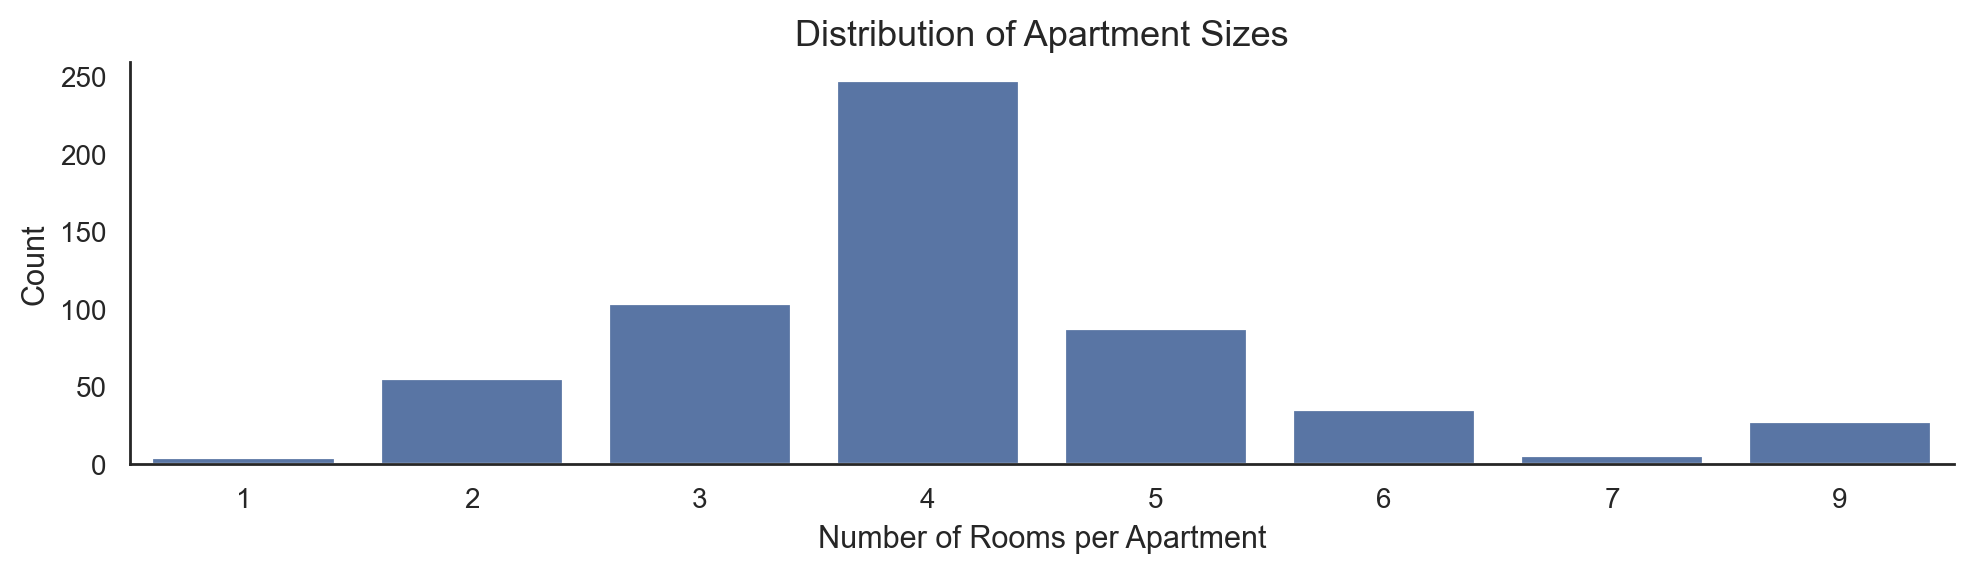

In [6]:
# ======================================
# Distribution of Apartment Sizes
# ======================================

plt.figure(figsize=(10, 3))

sns.countplot(
    data=merged_df,
    x="ApartmentSize",
    order=sorted(
        merged_df["ApartmentSize"].dropna().unique()
    )
)

plt.title("Distribution of Apartment Sizes")
plt.xlabel("Number of Rooms per Apartment")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [7]:
# ======================================
# Tenure Overview
# ======================================

# ---- Average length of stay ----
avg_length_of_stay = merged_df["LengthOfStay_days"].mean()
print("Average length of stay (days):", round(avg_length_of_stay, 1))


# ---- Average remaining stay ----
avg_remaining_stay = merged_df["RemainingStay_days"].mean()
print("Average remaining stay (days):", round(avg_remaining_stay, 1))

Average length of stay (days): 136.2
Average remaining stay (days): 188.3


#### 2.2 Tenant Demographics

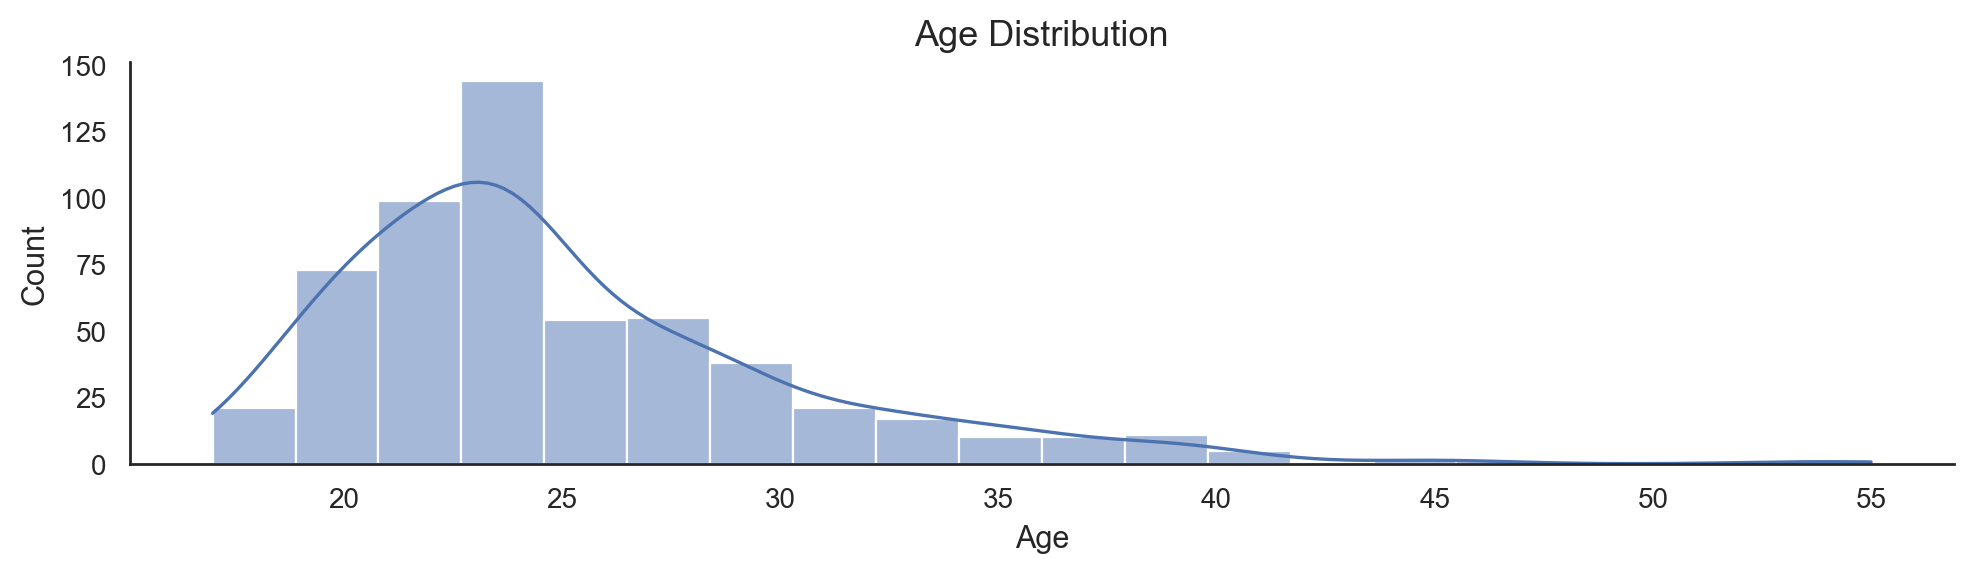

In [8]:
# ======================================
# Age Distribution
# ======================================

plt.figure(figsize=(10, 3))

sns.histplot(
    merged_df["Age"].dropna(),
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

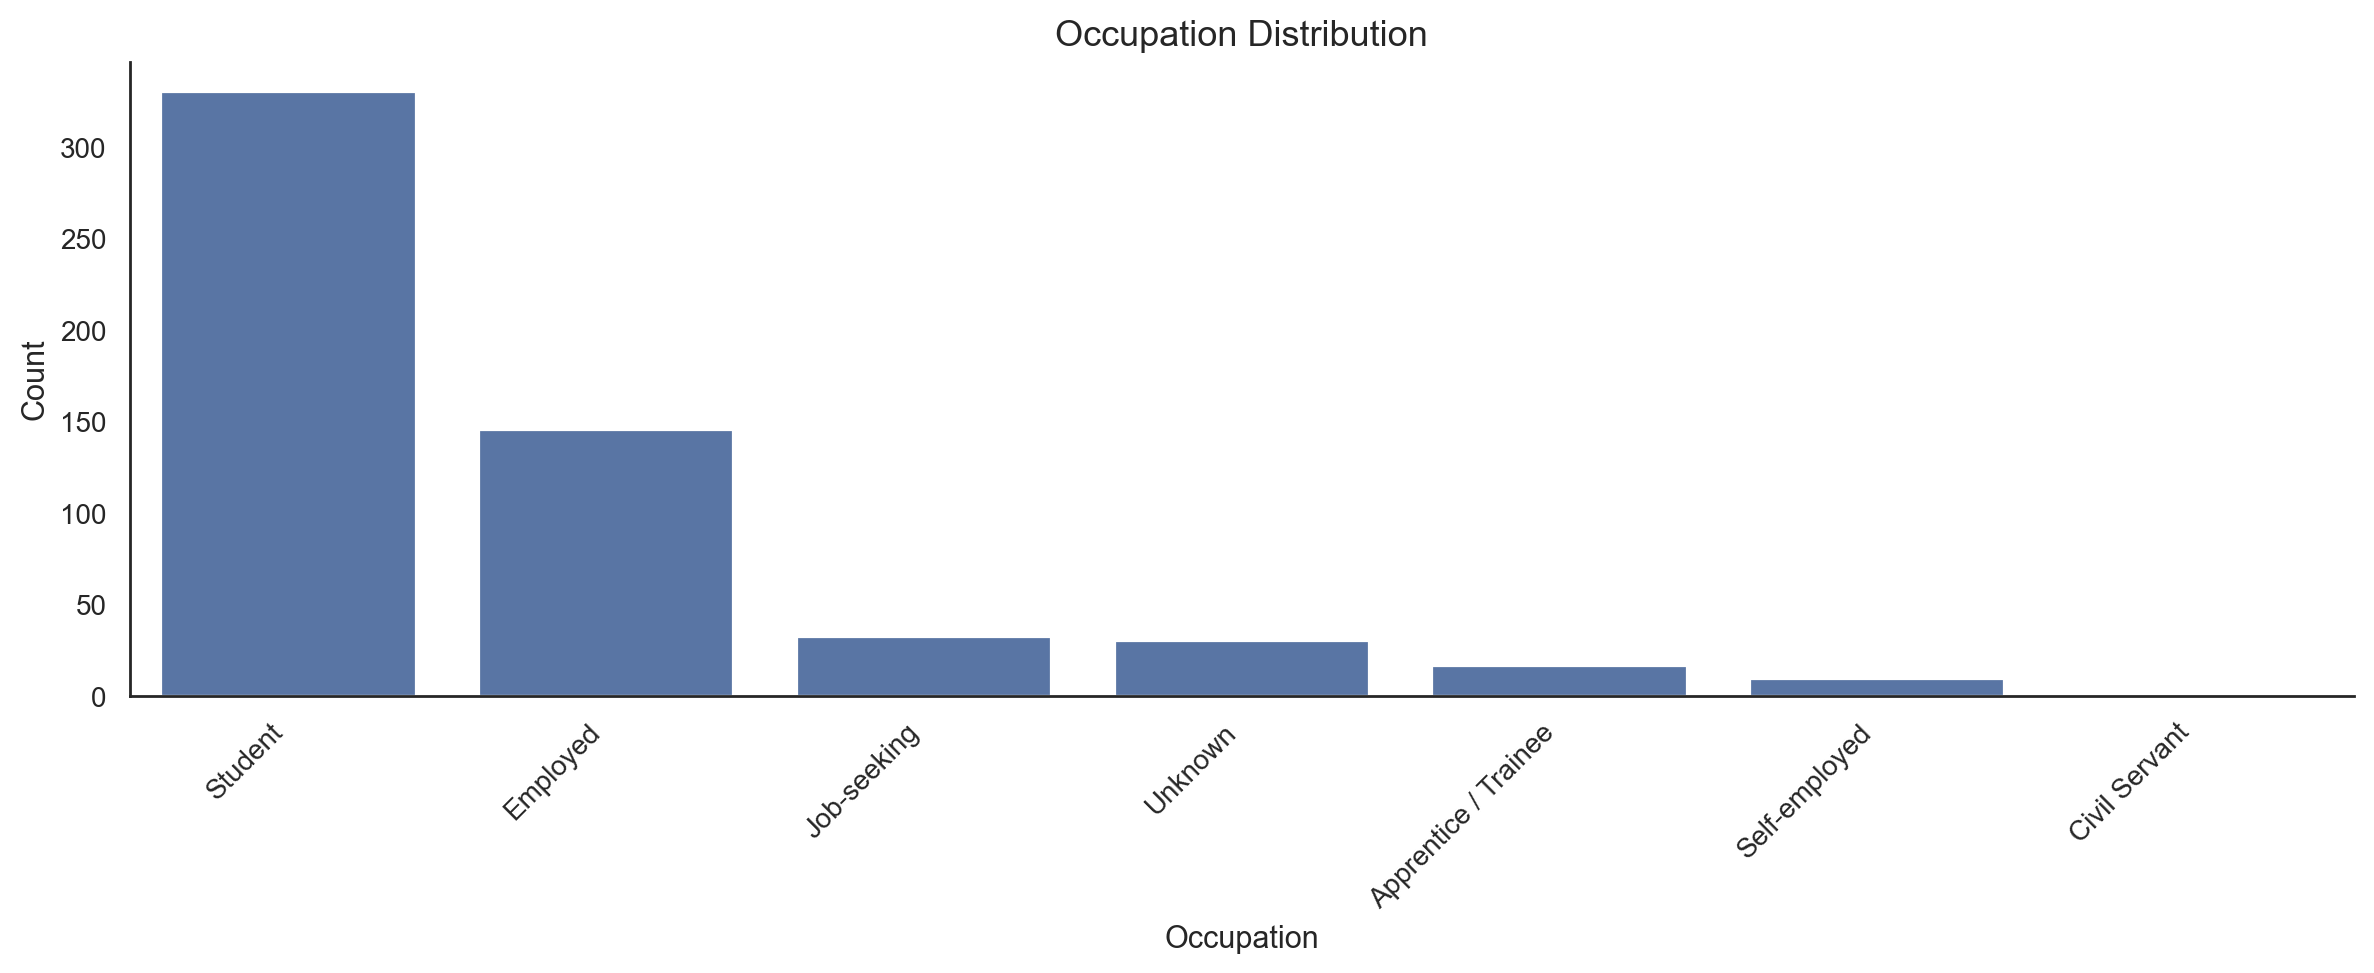

In [9]:
# ======================================
# Occupation Distribution
# ======================================

plt.figure(figsize=(12, 5))

sns.countplot(
    data=merged_df,
    x="Occupation",
    order=merged_df["Occupation"].value_counts().index
)

plt.title("Occupation Distribution")
plt.xlabel("Occupation")
plt.ylabel("Count")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

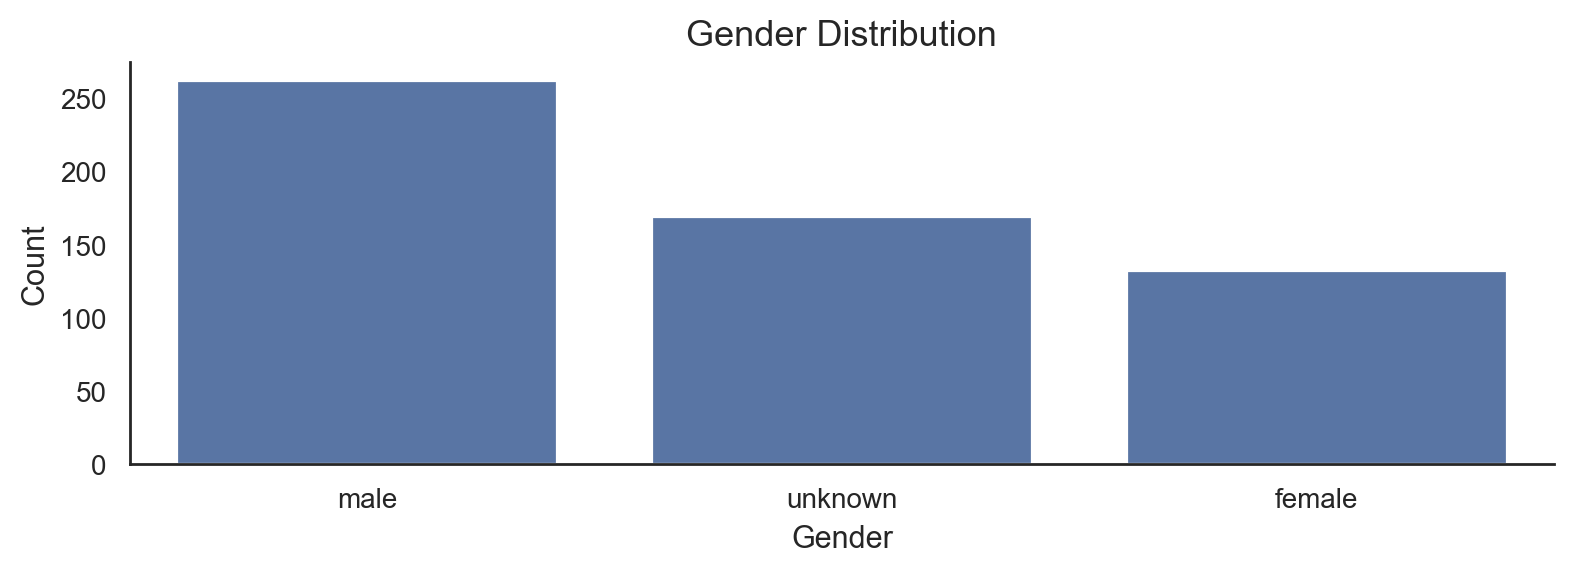

In [10]:
# ======================================
# Gender Distribution
# ======================================

plt.figure(figsize=(8, 3))

sns.countplot(
    data=merged_df,
    x="Gender"
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

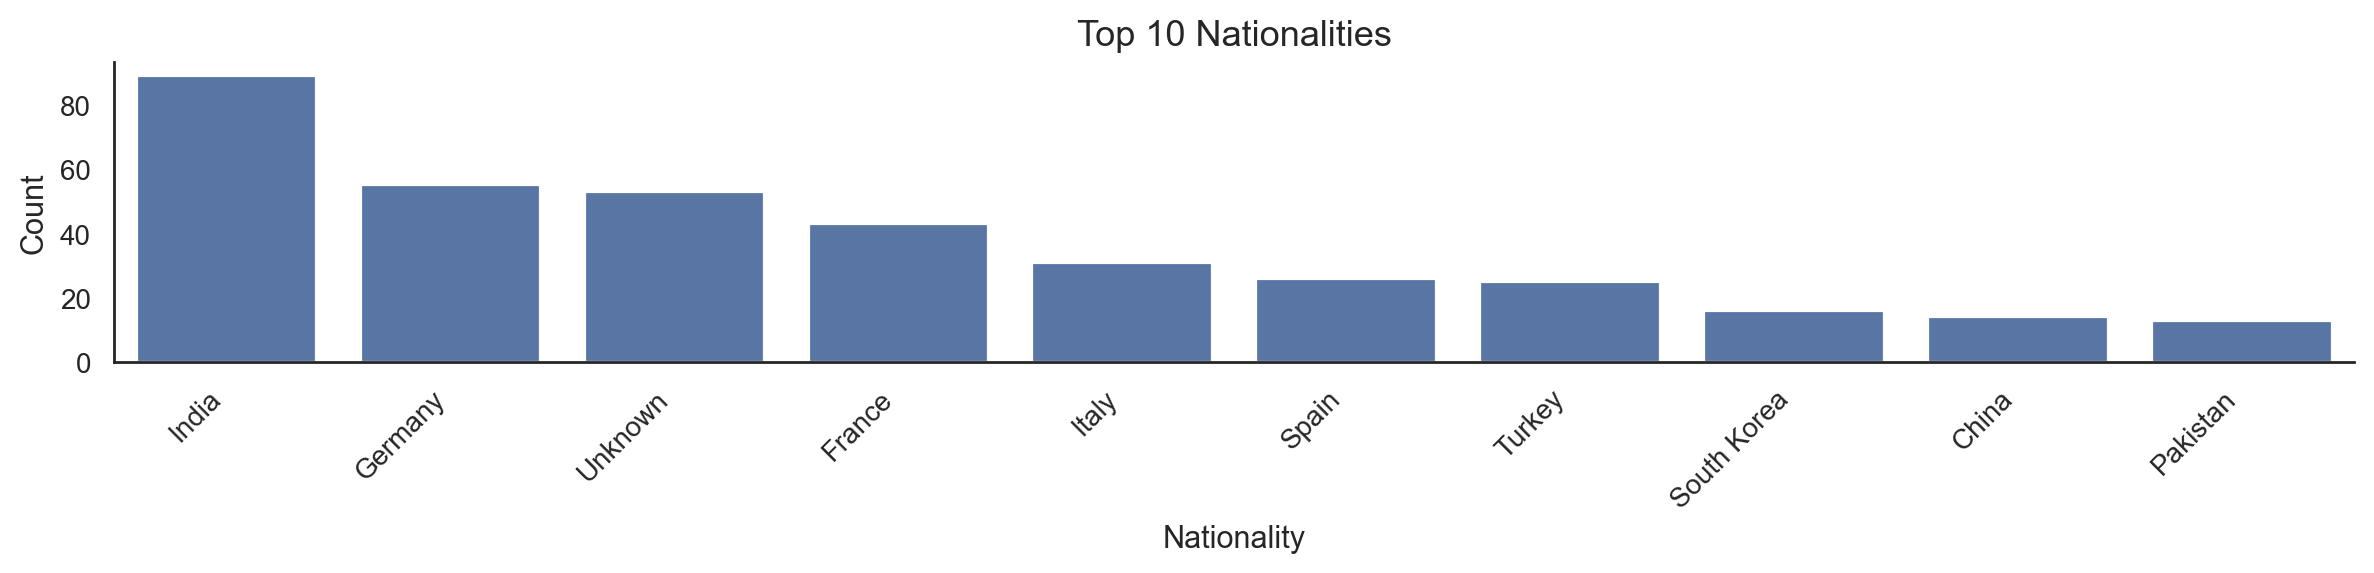

In [11]:
# ======================================
# Top 10 Nationalities
# ======================================

top_nationalities = (
    merged_df["Nationality"]
    .value_counts()
    .nlargest(10)
    .index
)

plt.figure(figsize=(12, 3))

sns.countplot(
    data=merged_df,
    x="Nationality",
    order=top_nationalities
)

plt.title("Top 10 Nationalities")
plt.xlabel("Nationality")
plt.ylabel("Count")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### 2.3 Personality Traits

In [12]:
# ======================================
# Big Five Personality Overview
# ======================================

personality_cols = [
    "Extraversion",
    "Agreeableness",
    "Conscientiousness",
    "Emotional_Stability",
    "Openness"
]

merged_df[personality_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Extraversion,563.0,2.985790,0.597870,1.0,2.5,3.0,3.5,4.5
Agreeableness,563.0,3.031083,0.590111,1.5,2.5,3.0,3.5,4.5
Conscientiousness,563.0,3.006217,0.607966,1.5,2.5,3.0,3.5,5.0
Emotional_Stability,563.0,2.953819,0.616065,1.0,2.5,3.0,3.5,5.0
Openness,563.0,2.988455,0.631576,1.5,2.5,3.0,3.5,5.0


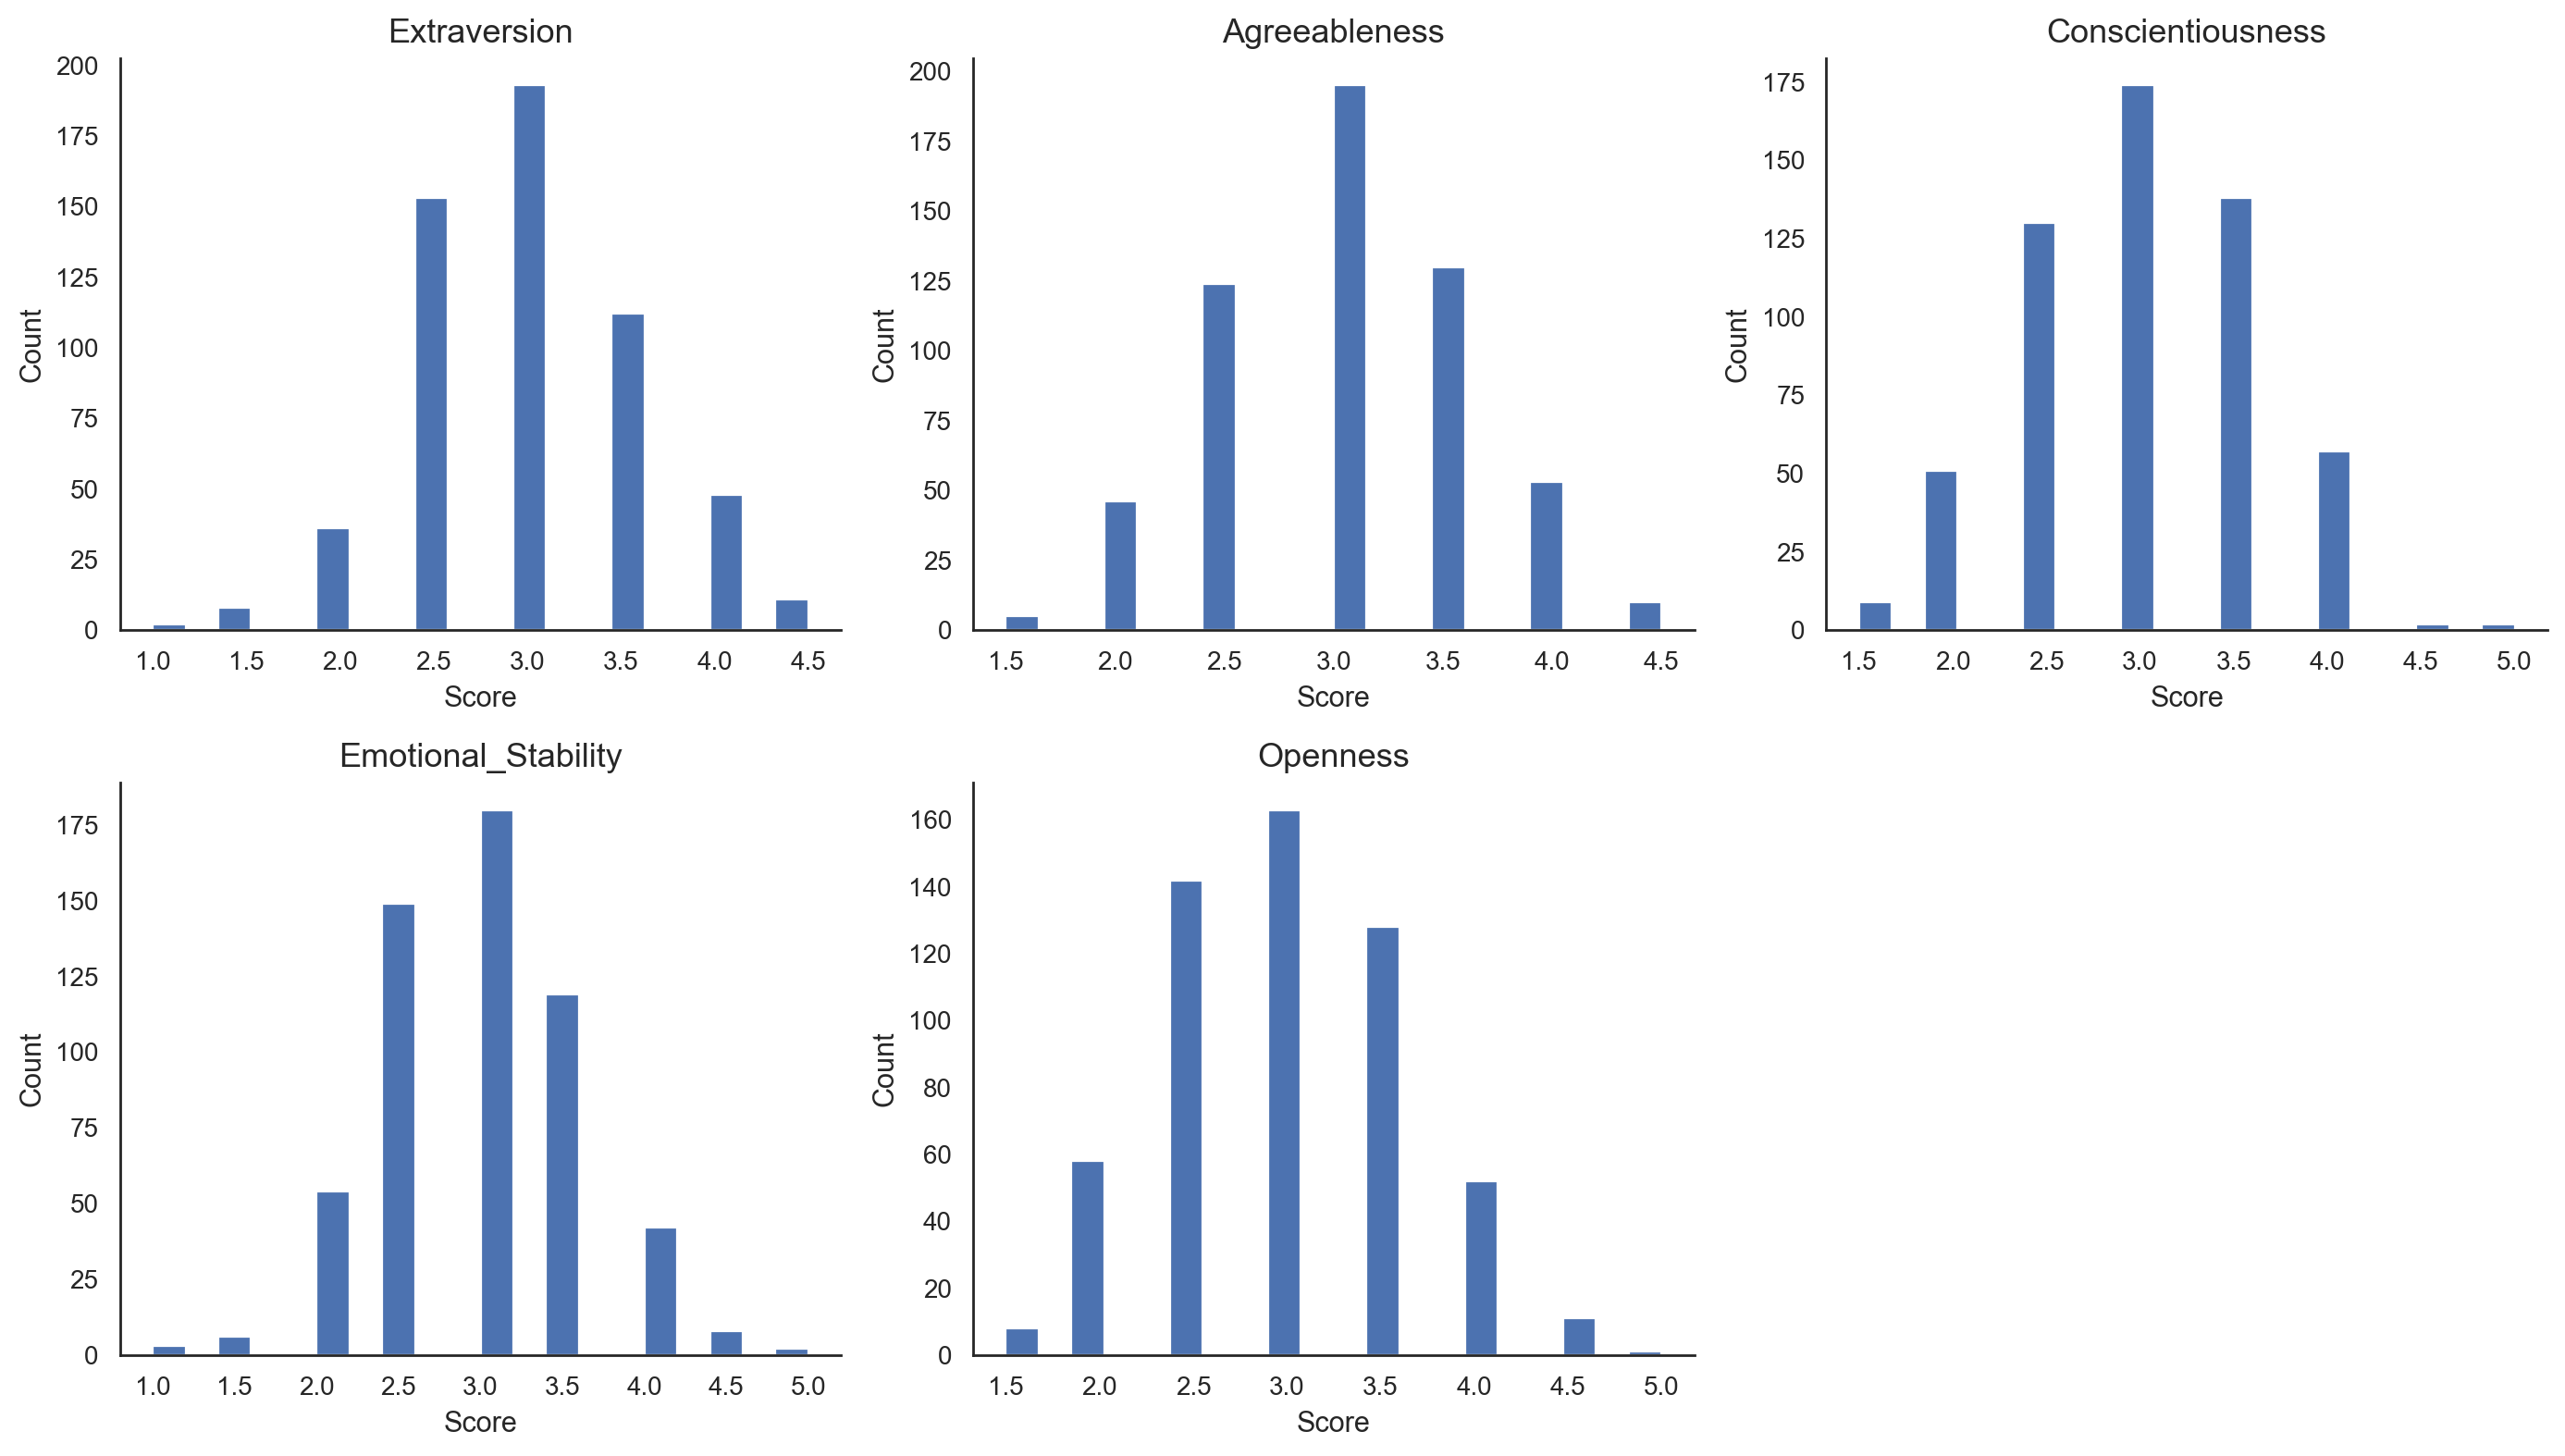

In [13]:
# ======================================
# Personality Trait Distributions
# ======================================

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, trait in zip(axes, personality_cols):
    ax.hist(merged_df[trait].dropna(), bins=20)
    ax.set_title(trait)
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")

# Hide unused subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()

#### 2.4 Lifestyle Preferences and Behavioral Patterns

In [14]:
# ======================================
# Category Order Definitions
# ======================================

plot_orders = {
    "Sleep_schedule": [
        "Before 22:00", "22:00-00:00", "00:00-02:00",
        "After 02:00", "Prefer not to say"
    ],
    "Noise_sensitivity": [
        "Very insensitive", "Somewhat insensitive", "Neutral",
        "Somewhat sensitive", "Very sensitive"
    ],
    "Cleanliness": [
        "Not at all important", "Slightly important",
        "Moderately important", "Very important",
        "Extremely important"
    ],
    "Cleanliness_2": [
        "Rarely", "Sometimes", "Often",
        "Most of the time", "Always"
    ],
    "Cooking_at_home": [
        "Never", "Rarely", "Once per week",
        "Several times per week", "Every day"
    ],
    "Guests_over": [
        "Never", "Rarely", "A few times per month",
        "Once per week", "Several times per week"
    ],
    "Smoking": ["Non-smoker", "Smoker"],
    "Alcohol": [
        "Never", "Rarely", "Sometimes",
        "Often", "Very often"
    ],
    "Vibe": [
        "Quiet & private", "Mostly private",
        "Balanced", "Social & lively", "Very social"
    ],
    "Chores": [
        "Avoid them", "Do them when asked",
        "Do my fair share", "Often take initiative",
        "Take responsibility for most"
    ],
    "Conflict": [
        "Avoid confrontation",
        "Try to solve problems through discussion",
        "Compromise quickly",
        "Be direct, even if uncomfortable",
        "Prefer not to say"
    ]
}

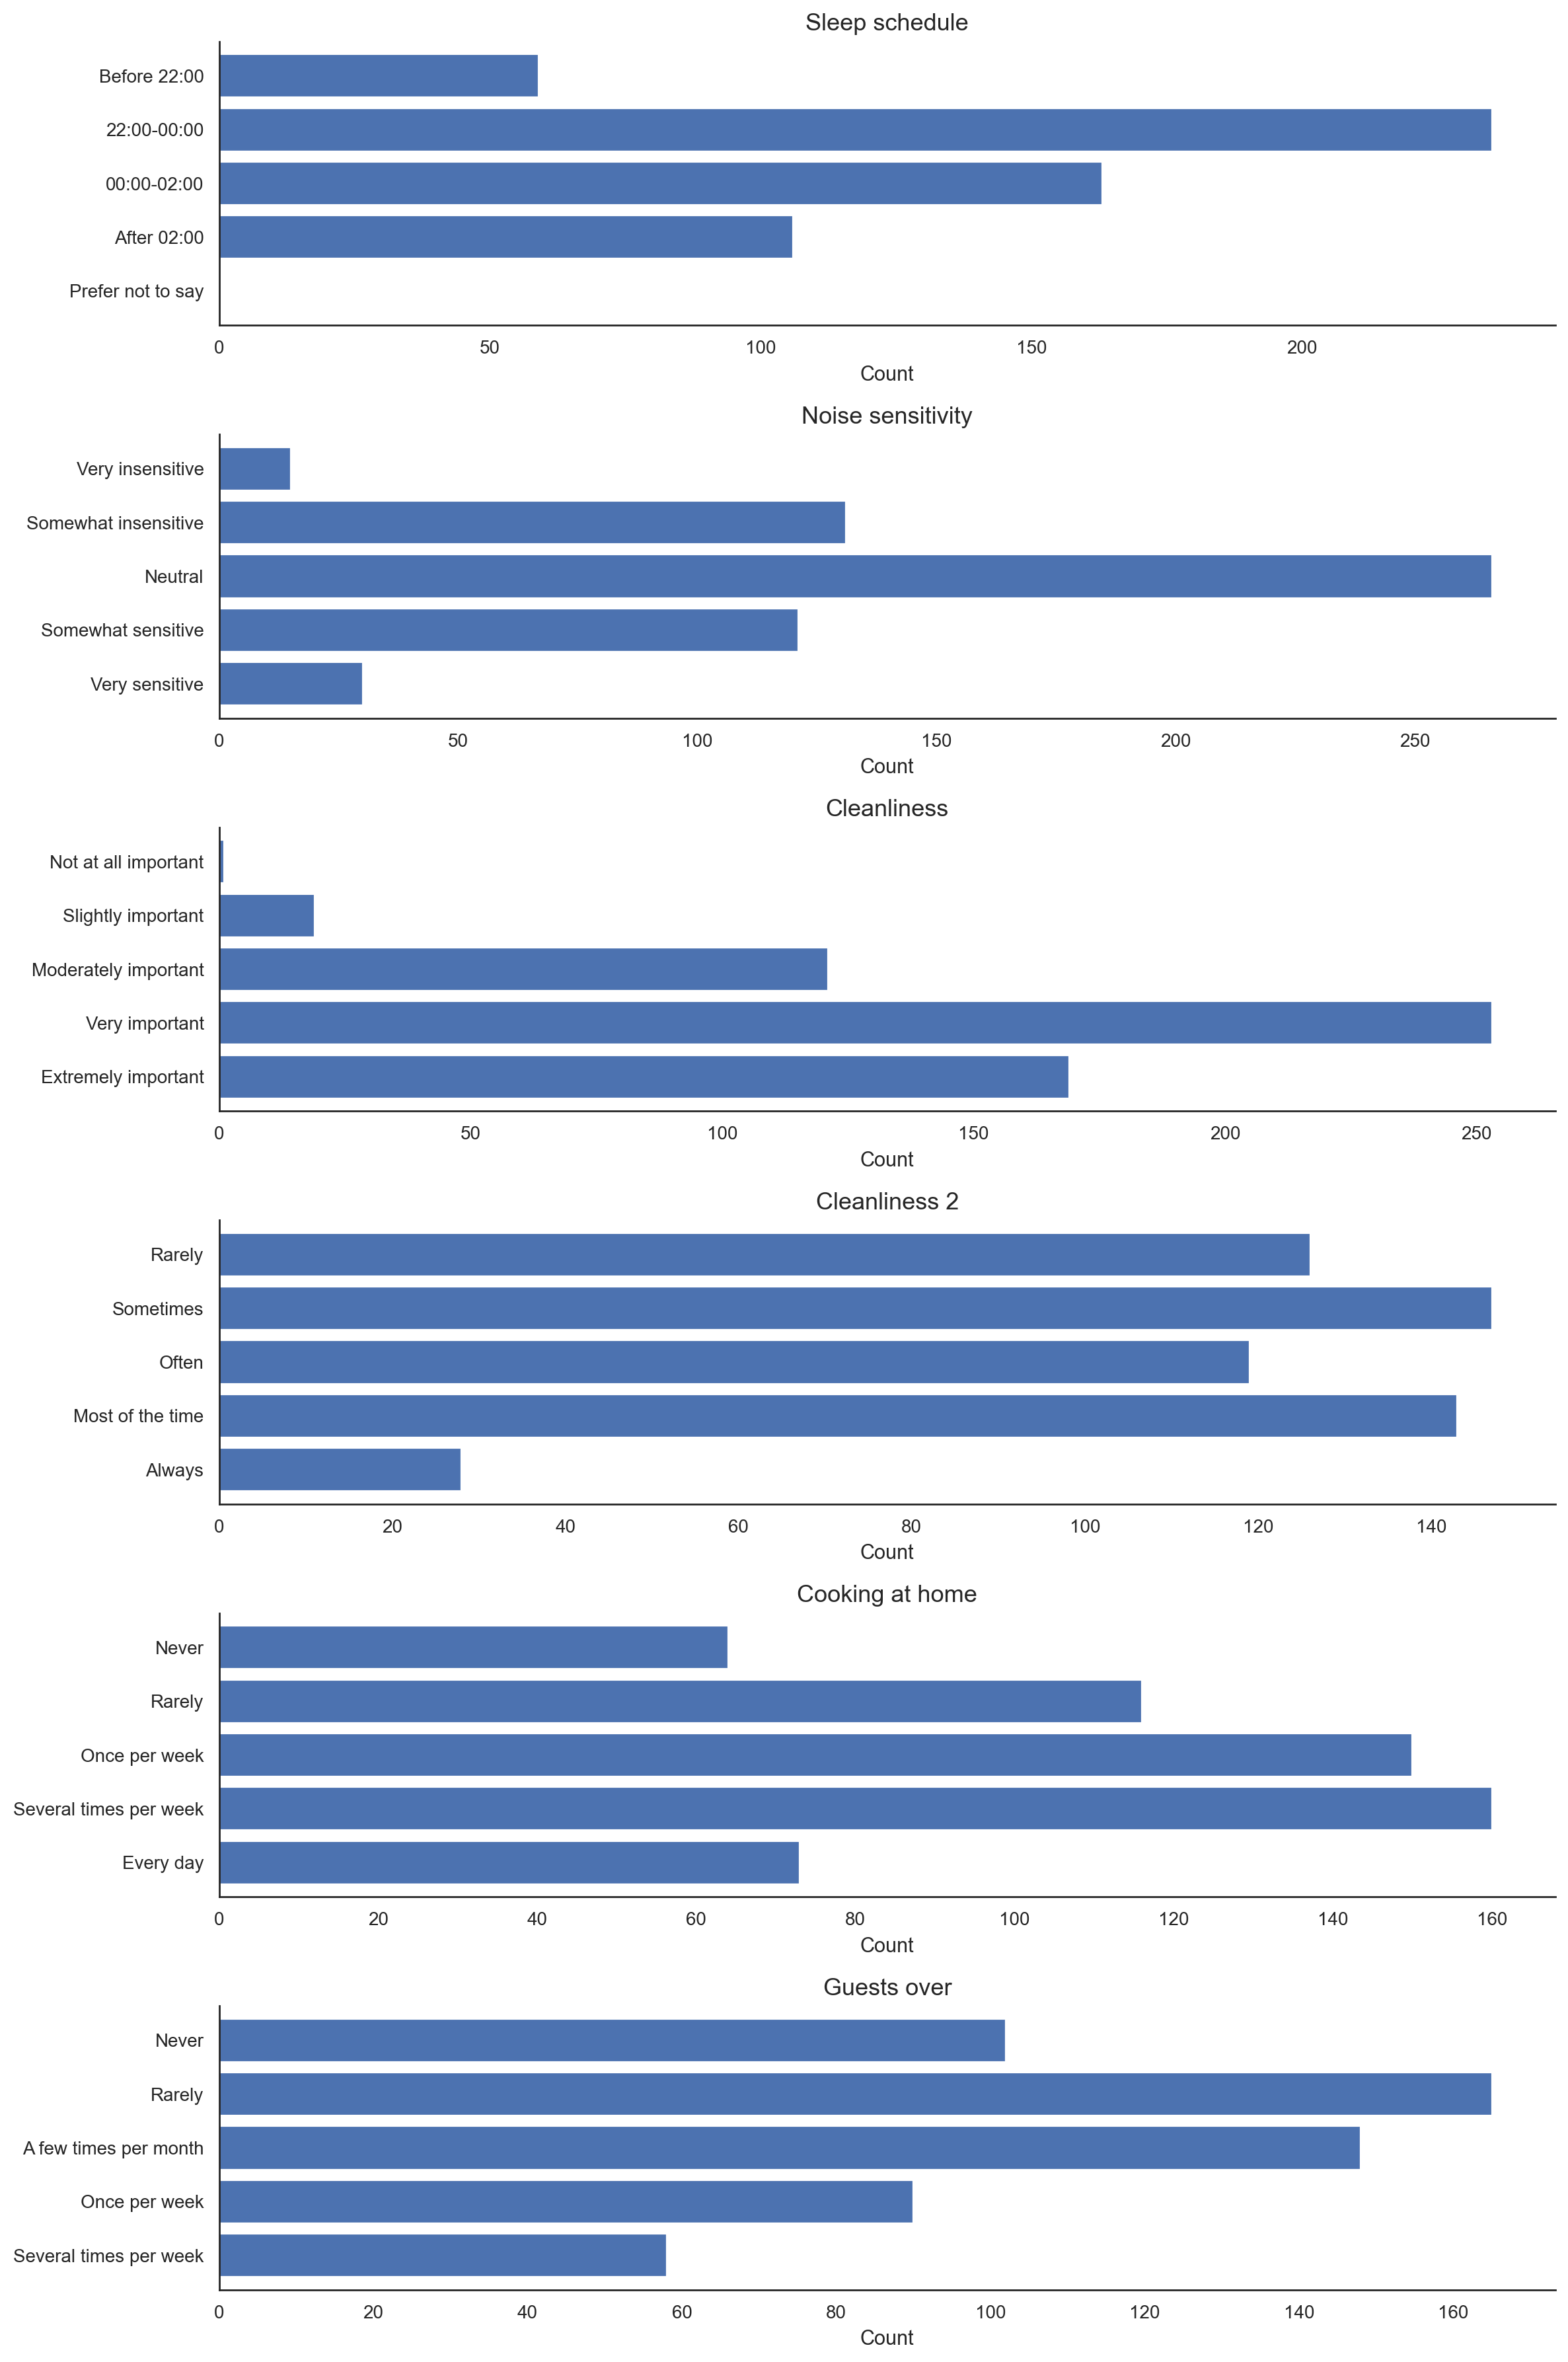

In [15]:
# ======================================
# Lifestyle & Preference Distributions I
# ======================================

vars_to_plot_1 = [
    "Sleep_schedule",
    "Noise_sensitivity",
    "Cleanliness",
    "Cleanliness_2",
    "Cooking_at_home",
    "Guests_over",
]

fig, axes = plt.subplots(
    len(vars_to_plot_1),
    1,
    figsize=(12, 3 * len(vars_to_plot_1))
)

if len(vars_to_plot_1) == 1:
    axes = [axes]

for ax, var in zip(axes, vars_to_plot_1):

    order = plot_orders[var]
    counts = merged_df[var].value_counts()

    extras = [x for x in counts.index if x not in order]
    full_order = order + extras

    counts = counts.reindex(full_order, fill_value=0)

    ax.barh(full_order, counts.values)
    ax.set_xlabel("Count")
    ax.set_ylabel("")
    ax.set_title(var.replace("_", " "))
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

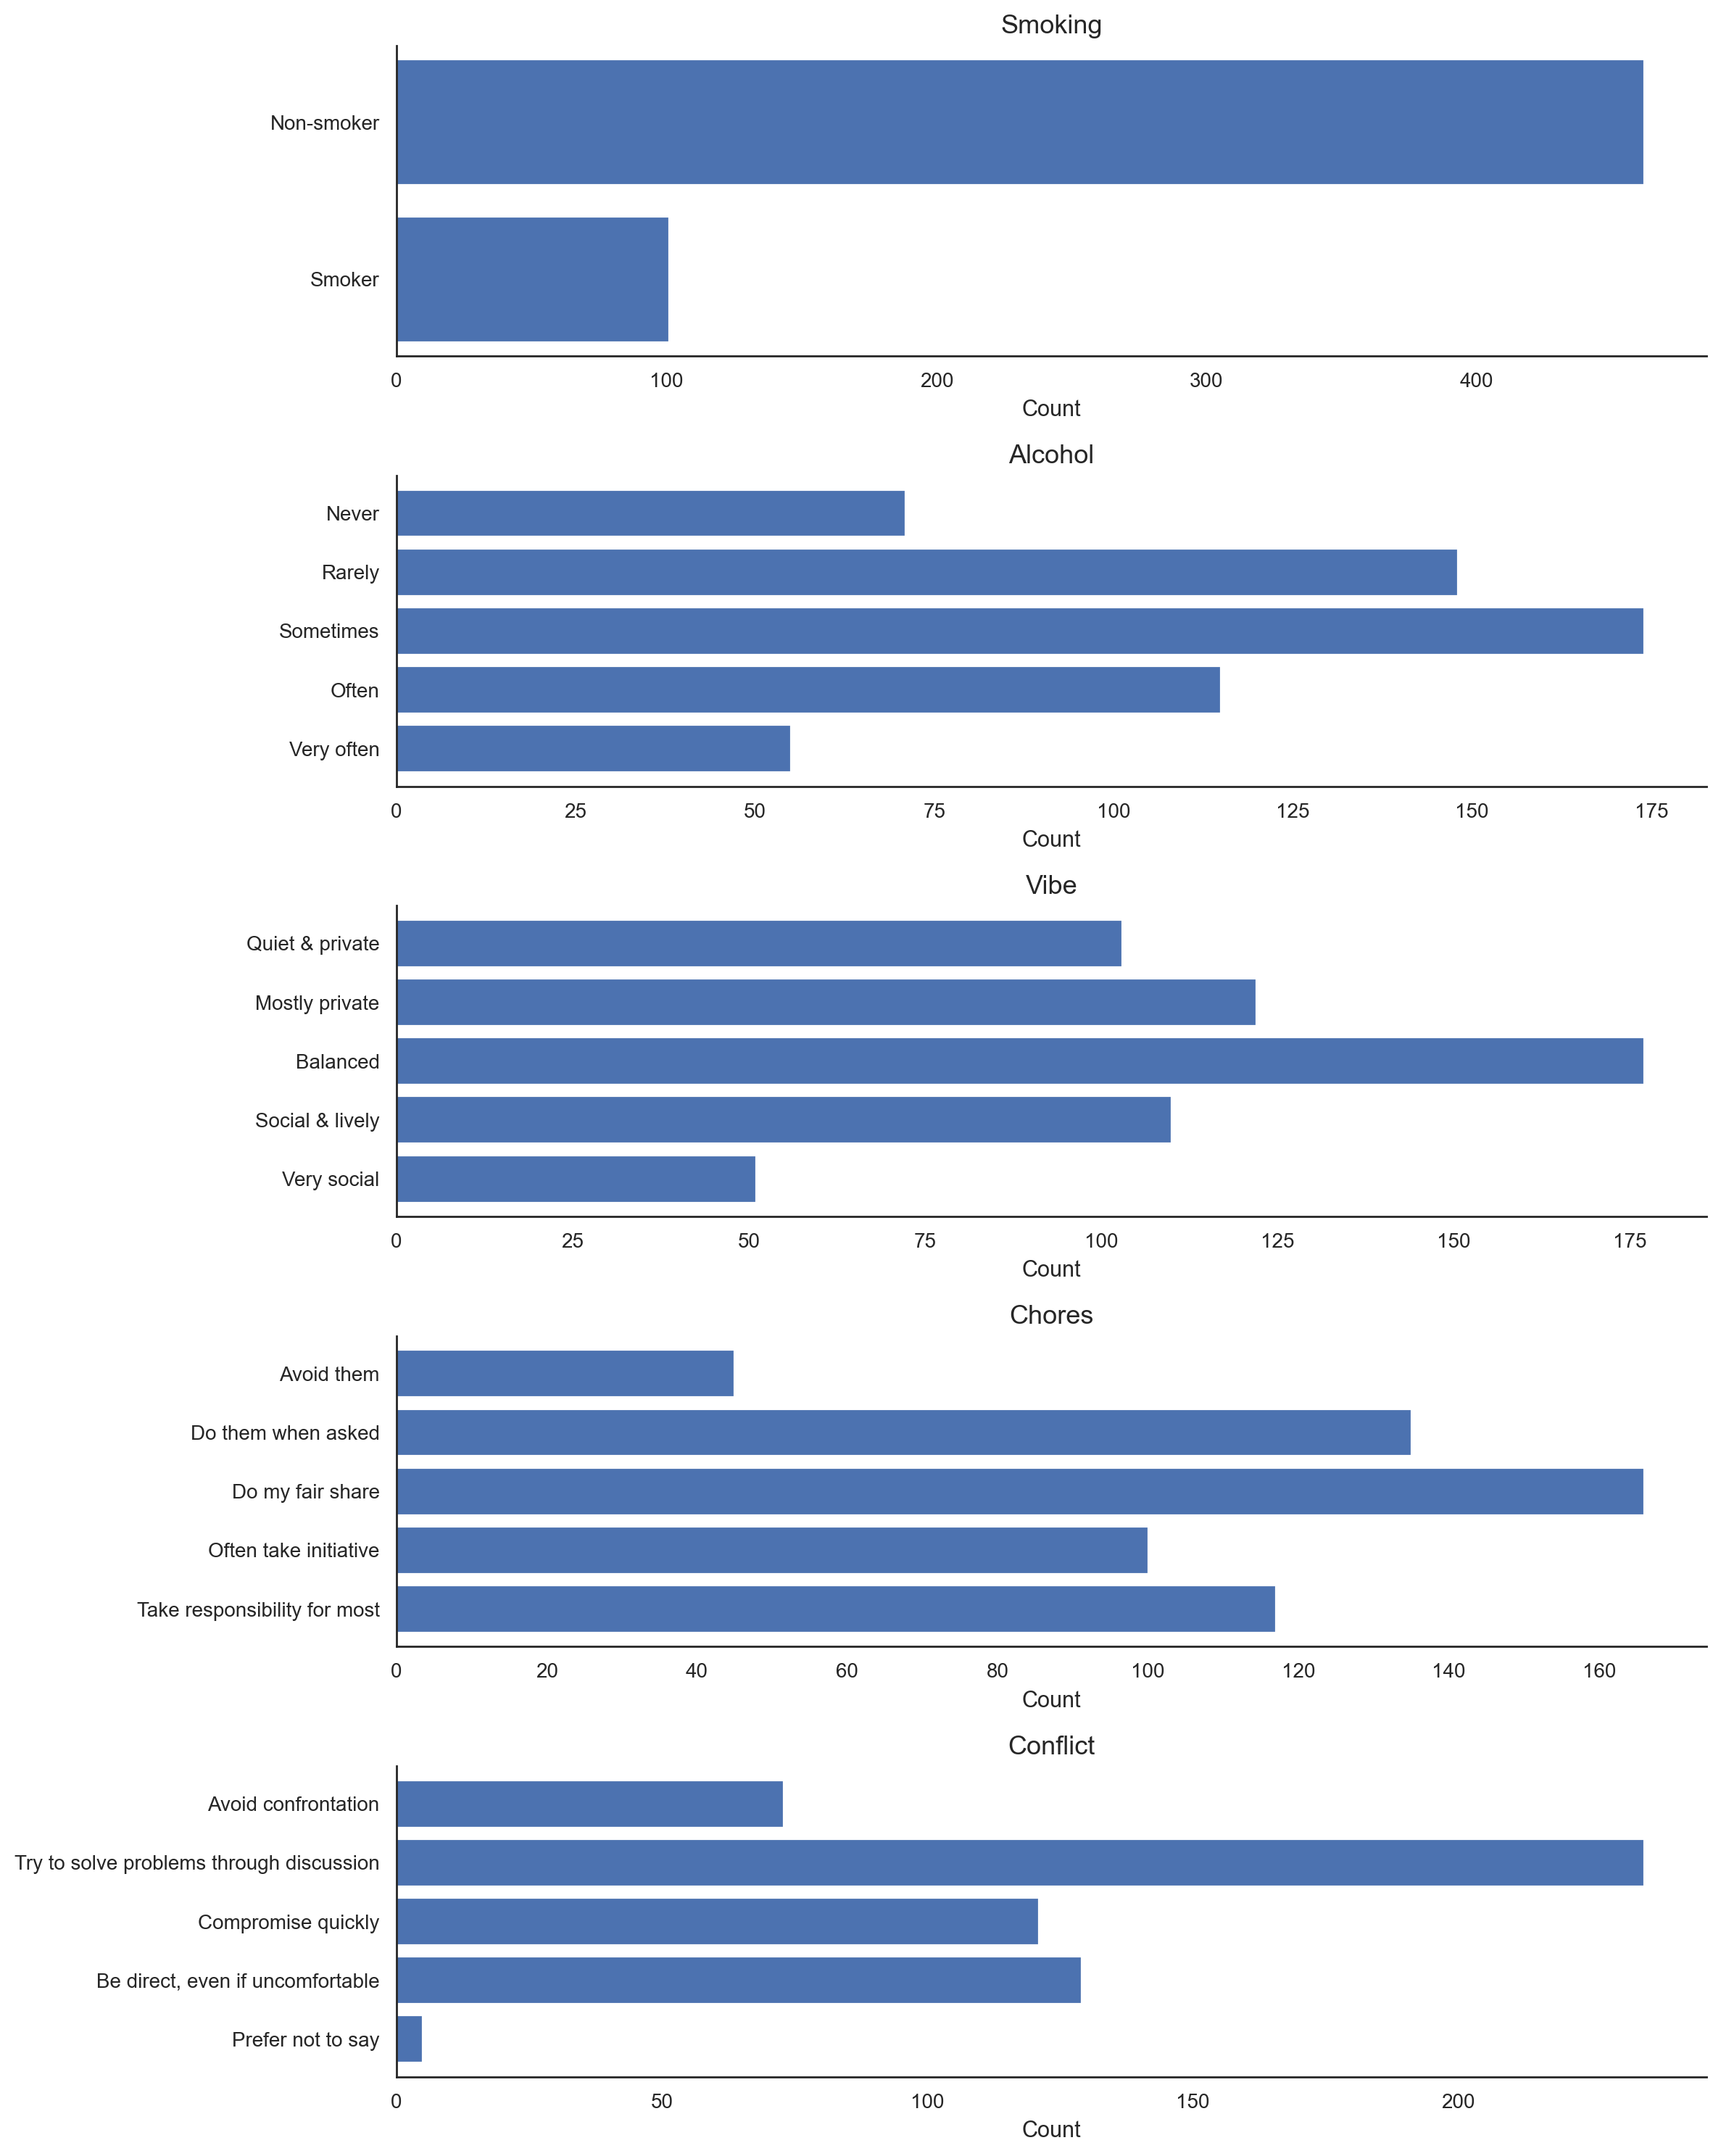

In [16]:
# ======================================
# Lifestyle & Preference Distributions II
# ======================================

vars_to_plot_2 = [
    "Smoking",
    "Alcohol",
    "Vibe",
    "Chores",
    "Conflict",
]

fig, axes = plt.subplots(
    len(vars_to_plot_2),
    1,
    figsize=(12, 3 * len(vars_to_plot_2))
)

if len(vars_to_plot_2) == 1:
    axes = [axes]

for ax, var in zip(axes, vars_to_plot_2):

    order = plot_orders[var]
    counts = merged_df[var].value_counts()

    extras = [x for x in counts.index if x not in order]
    full_order = order + extras

    counts = counts.reindex(full_order, fill_value=0)

    ax.barh(full_order, counts.values)
    ax.set_xlabel("Count")
    ax.set_ylabel("")
    ax.set_title(var.replace("_", " "))
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

#### 2.5 Flatmate Priority Factor and Importance

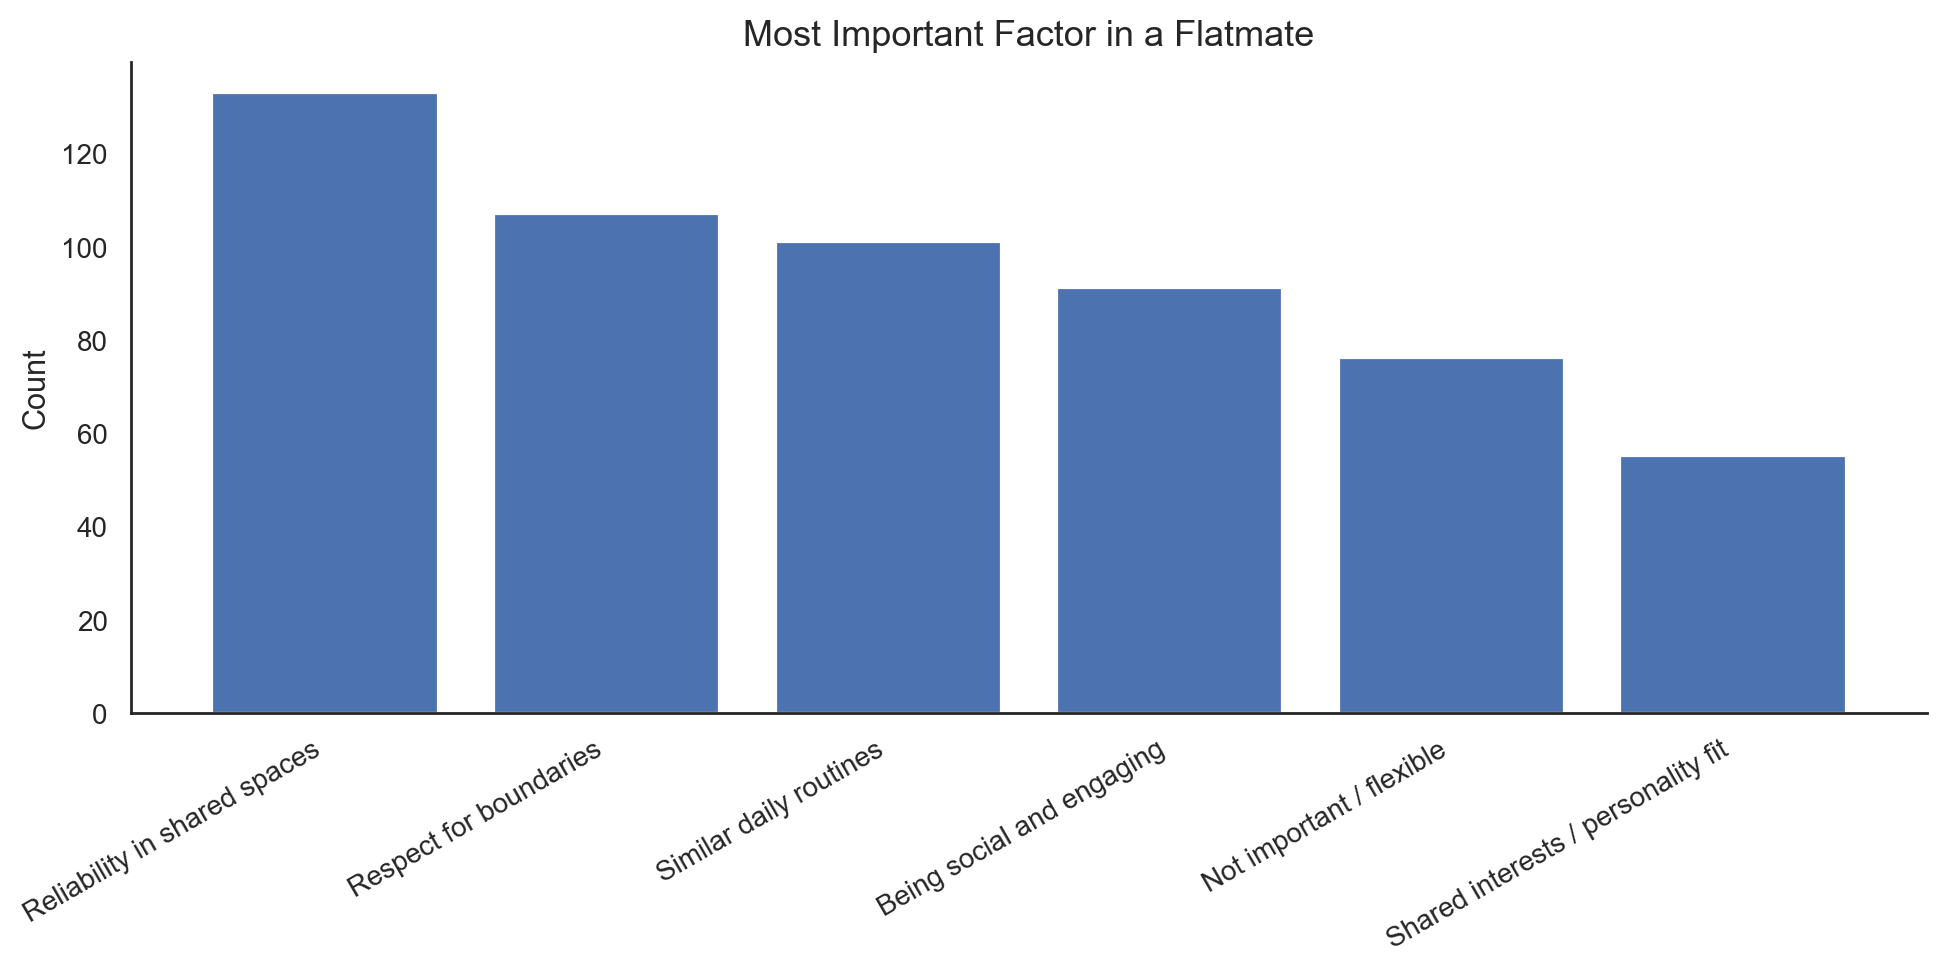

In [17]:
# ======================================
# Flatmate Priority Factor Distribution
# ======================================

counts = (
    merged_df["FlatmateFactors_Priority"]
    .value_counts()
)

plt.figure(figsize=(10, 5))

plt.bar(
    counts.index,
    counts.values
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Count")
plt.title("Most Important Factor in a Flatmate")

plt.tight_layout()
plt.show()

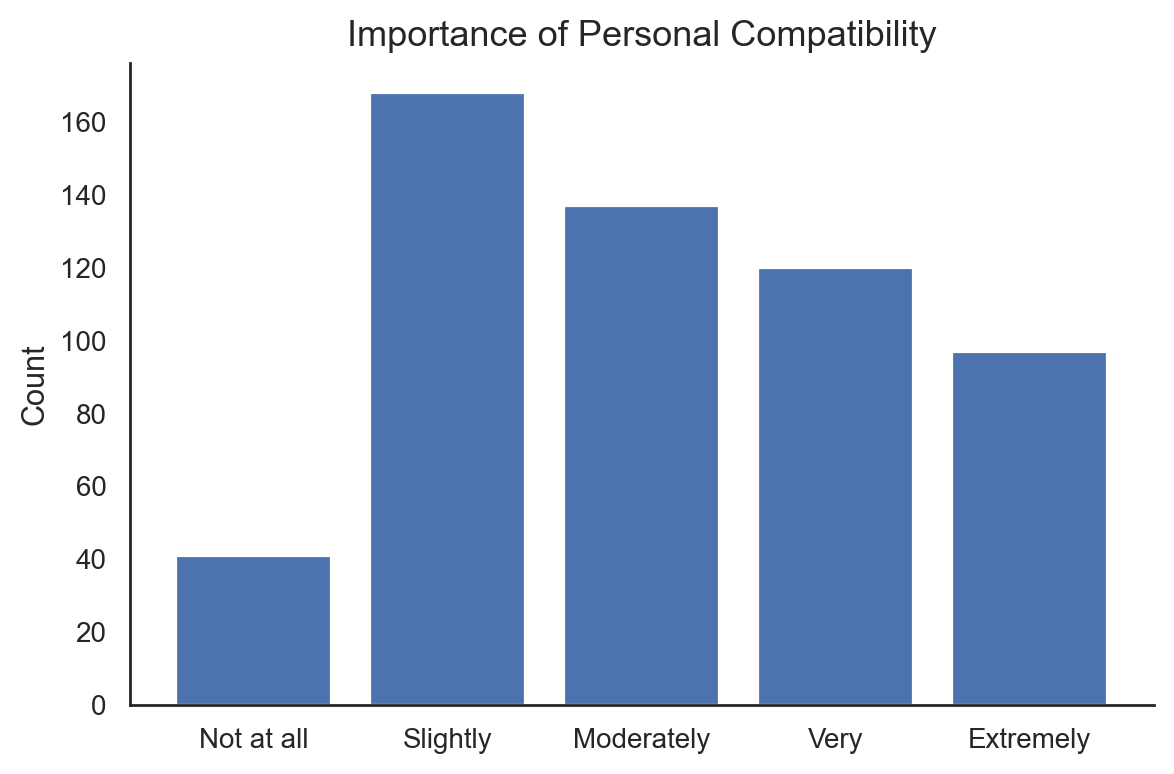

In [18]:
# ======================================
# Importance of Compatibility
# ======================================

order = ["Not at all", "Slightly", "Moderately", "Very", "Extremely"] 

counts = (
    merged_df["Compatibility_Importance"]
    .value_counts()
    .reindex(order, fill_value=0)
)

plt.figure(figsize=(6, 4))

plt.bar(
    counts.index,
    counts.values
)

plt.ylabel("Count")
plt.title("Importance of Personal Compatibility")

plt.tight_layout()
plt.show()

#### 2.6 Perceived Group-Level Compatibility

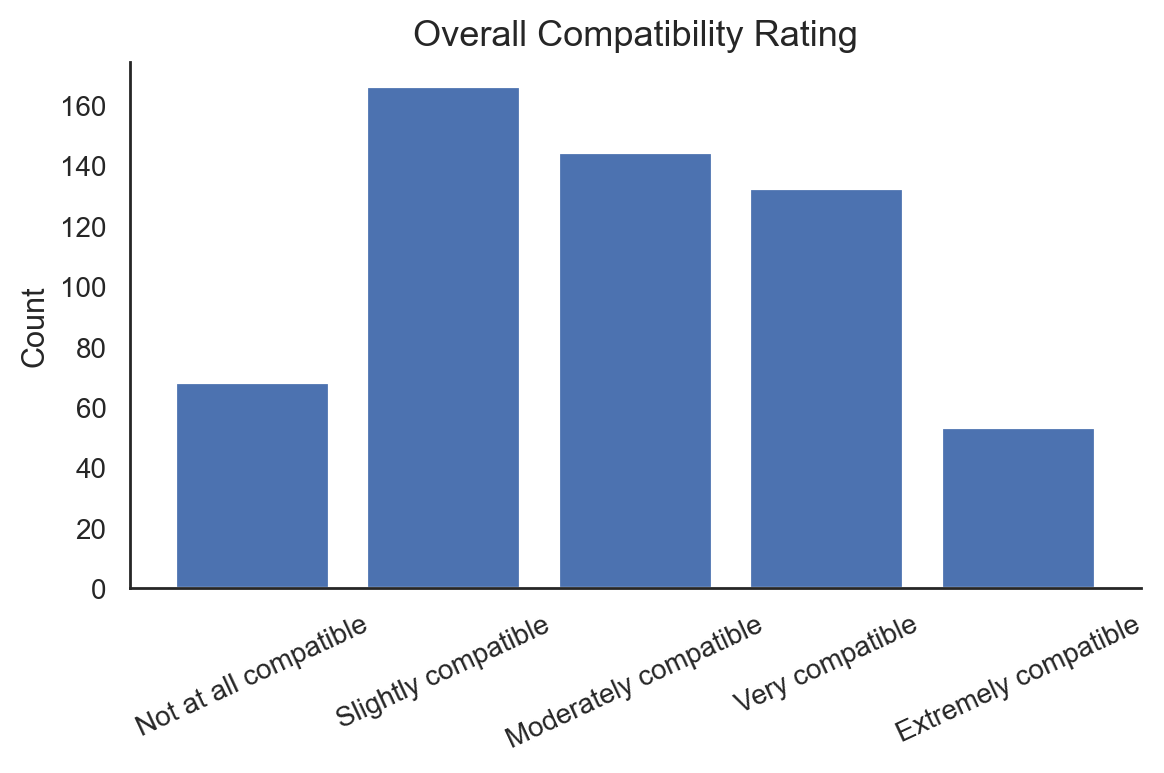

In [19]:
# ======================================
# Overall Compatibility Rating Distribution
# ======================================

overall_order = [
    "Not at all compatible",
    "Slightly compatible",
    "Moderately compatible",
    "Very compatible",
    "Extremely compatible"
]

counts = (
    merged_df["Compatibility_OverallRating"]
    .value_counts()
    .reindex(overall_order, fill_value=0)
)

plt.figure(figsize=(6, 4))

plt.bar(
    counts.index,
    counts.values
)

plt.ylabel("Count")
plt.title("Overall Compatibility Rating")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

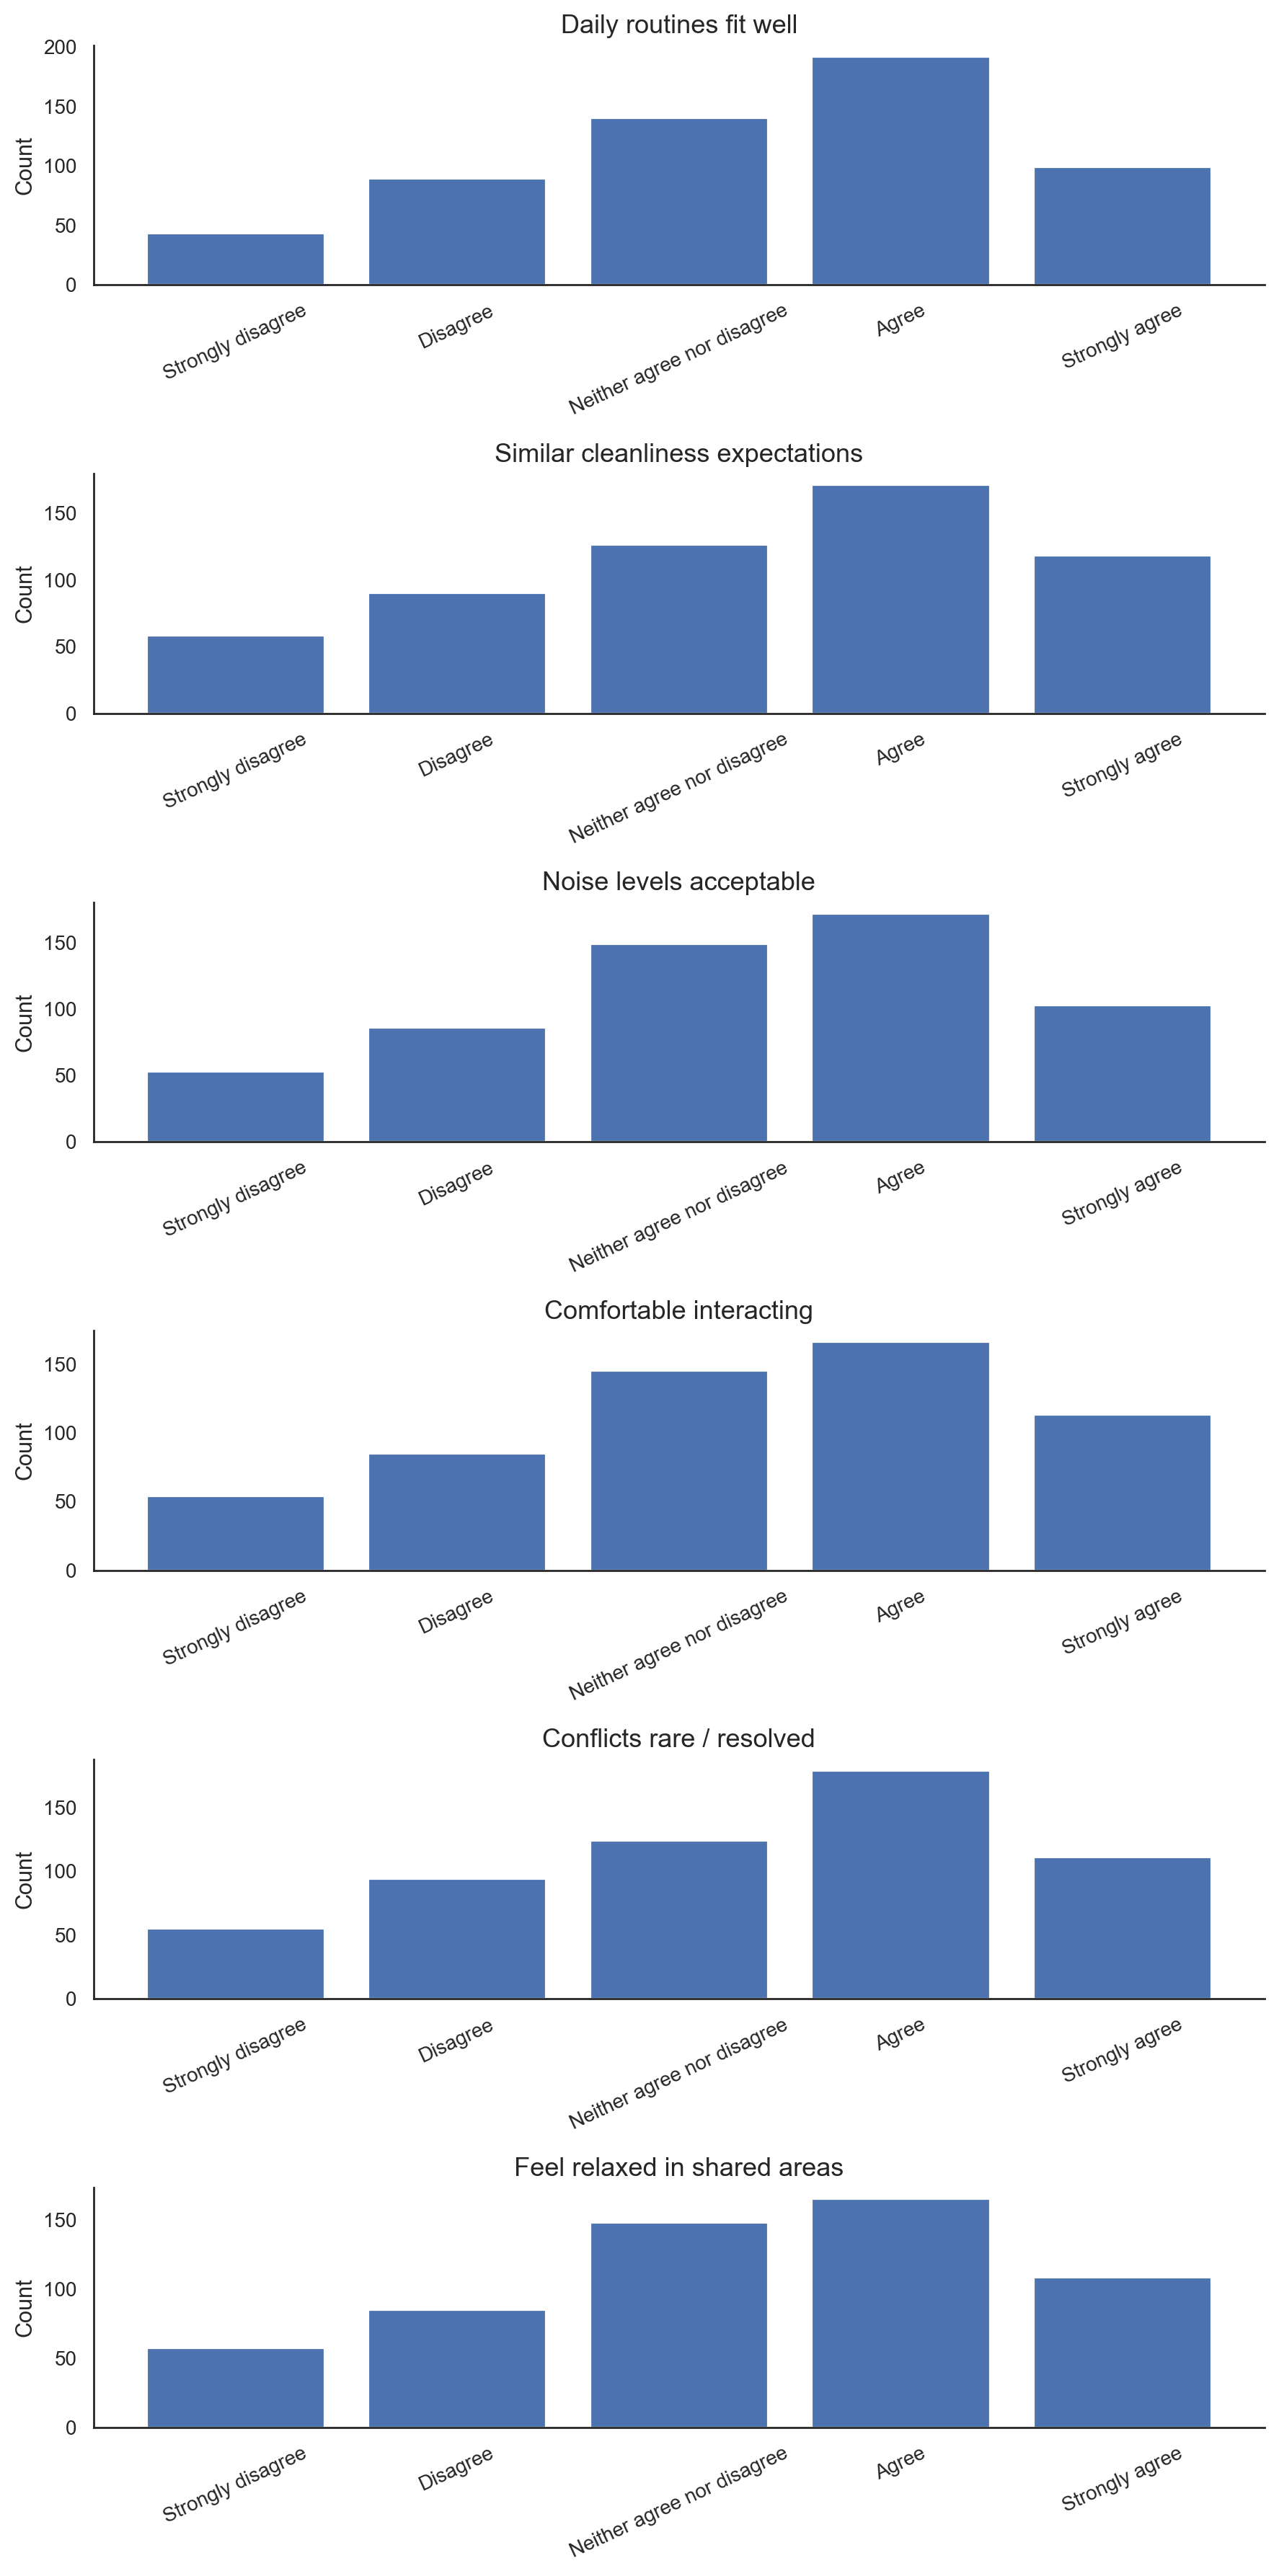

In [20]:
# ======================================
# Compatibility Facet Ratings (incl. Overall)
# ======================================

likert_order = [
    "Strongly disagree",
    "Disagree",
    "Neither agree nor disagree",
    "Agree",
    "Strongly agree"
]

facet_cols = {
    "Compat_DailyRoutines": "Daily routines fit well",
    "Compat_Tidiness": "Similar cleanliness expectations",
    "Compat_Noise": "Noise levels acceptable",
    "Compat_Interaction": "Comfortable interacting",
    "Compat_Conflict": "Conflicts rare / resolved",
    "Compat_Relaxedness": "Feel relaxed in shared areas"
}

fig, axes = plt.subplots(
    len(facet_cols),
    1,
    figsize=(9, 3 * len(facet_cols))
)

if len(facet_cols) == 1:
    axes = [axes]

for ax, (col, title) in zip(axes, facet_cols.items()):

    counts = (
        merged_df[col]
        .value_counts()
        .reindex(likert_order, fill_value=0)
    )

    ax.bar(counts.index, counts.values)
    ax.set_title(title)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

In [21]:
# ======================================
# Apartment-Level Perceived Compatibility (Mean & Dispersion)
# ======================================

apt_agreement = (
    merged_df
    .groupby("Apartment")["Compatibility_OverallRating_num"]
    .agg(
        mean="mean",
        within_apartment_std="std",
        count="count"
    )
    .sort_values("mean", ascending=False)
)

apt_agreement.head(50)

,mean,within_apartment_std,count
Apartment,,,
PXC.04,5.000000,NaN,1
PXJ.02,5.000000,NaN,1
PXB.03,4.666667,0.577350,3
PXB.17,4.500000,0.577350,4
PXE.12,4.500000,0.707107,2
PXE.22,4.000000,NaN,1
PXB.11,4.000000,0.000000,3
PXC.13,4.000000,NaN,1
PXE.06,4.000000,1.414214,2


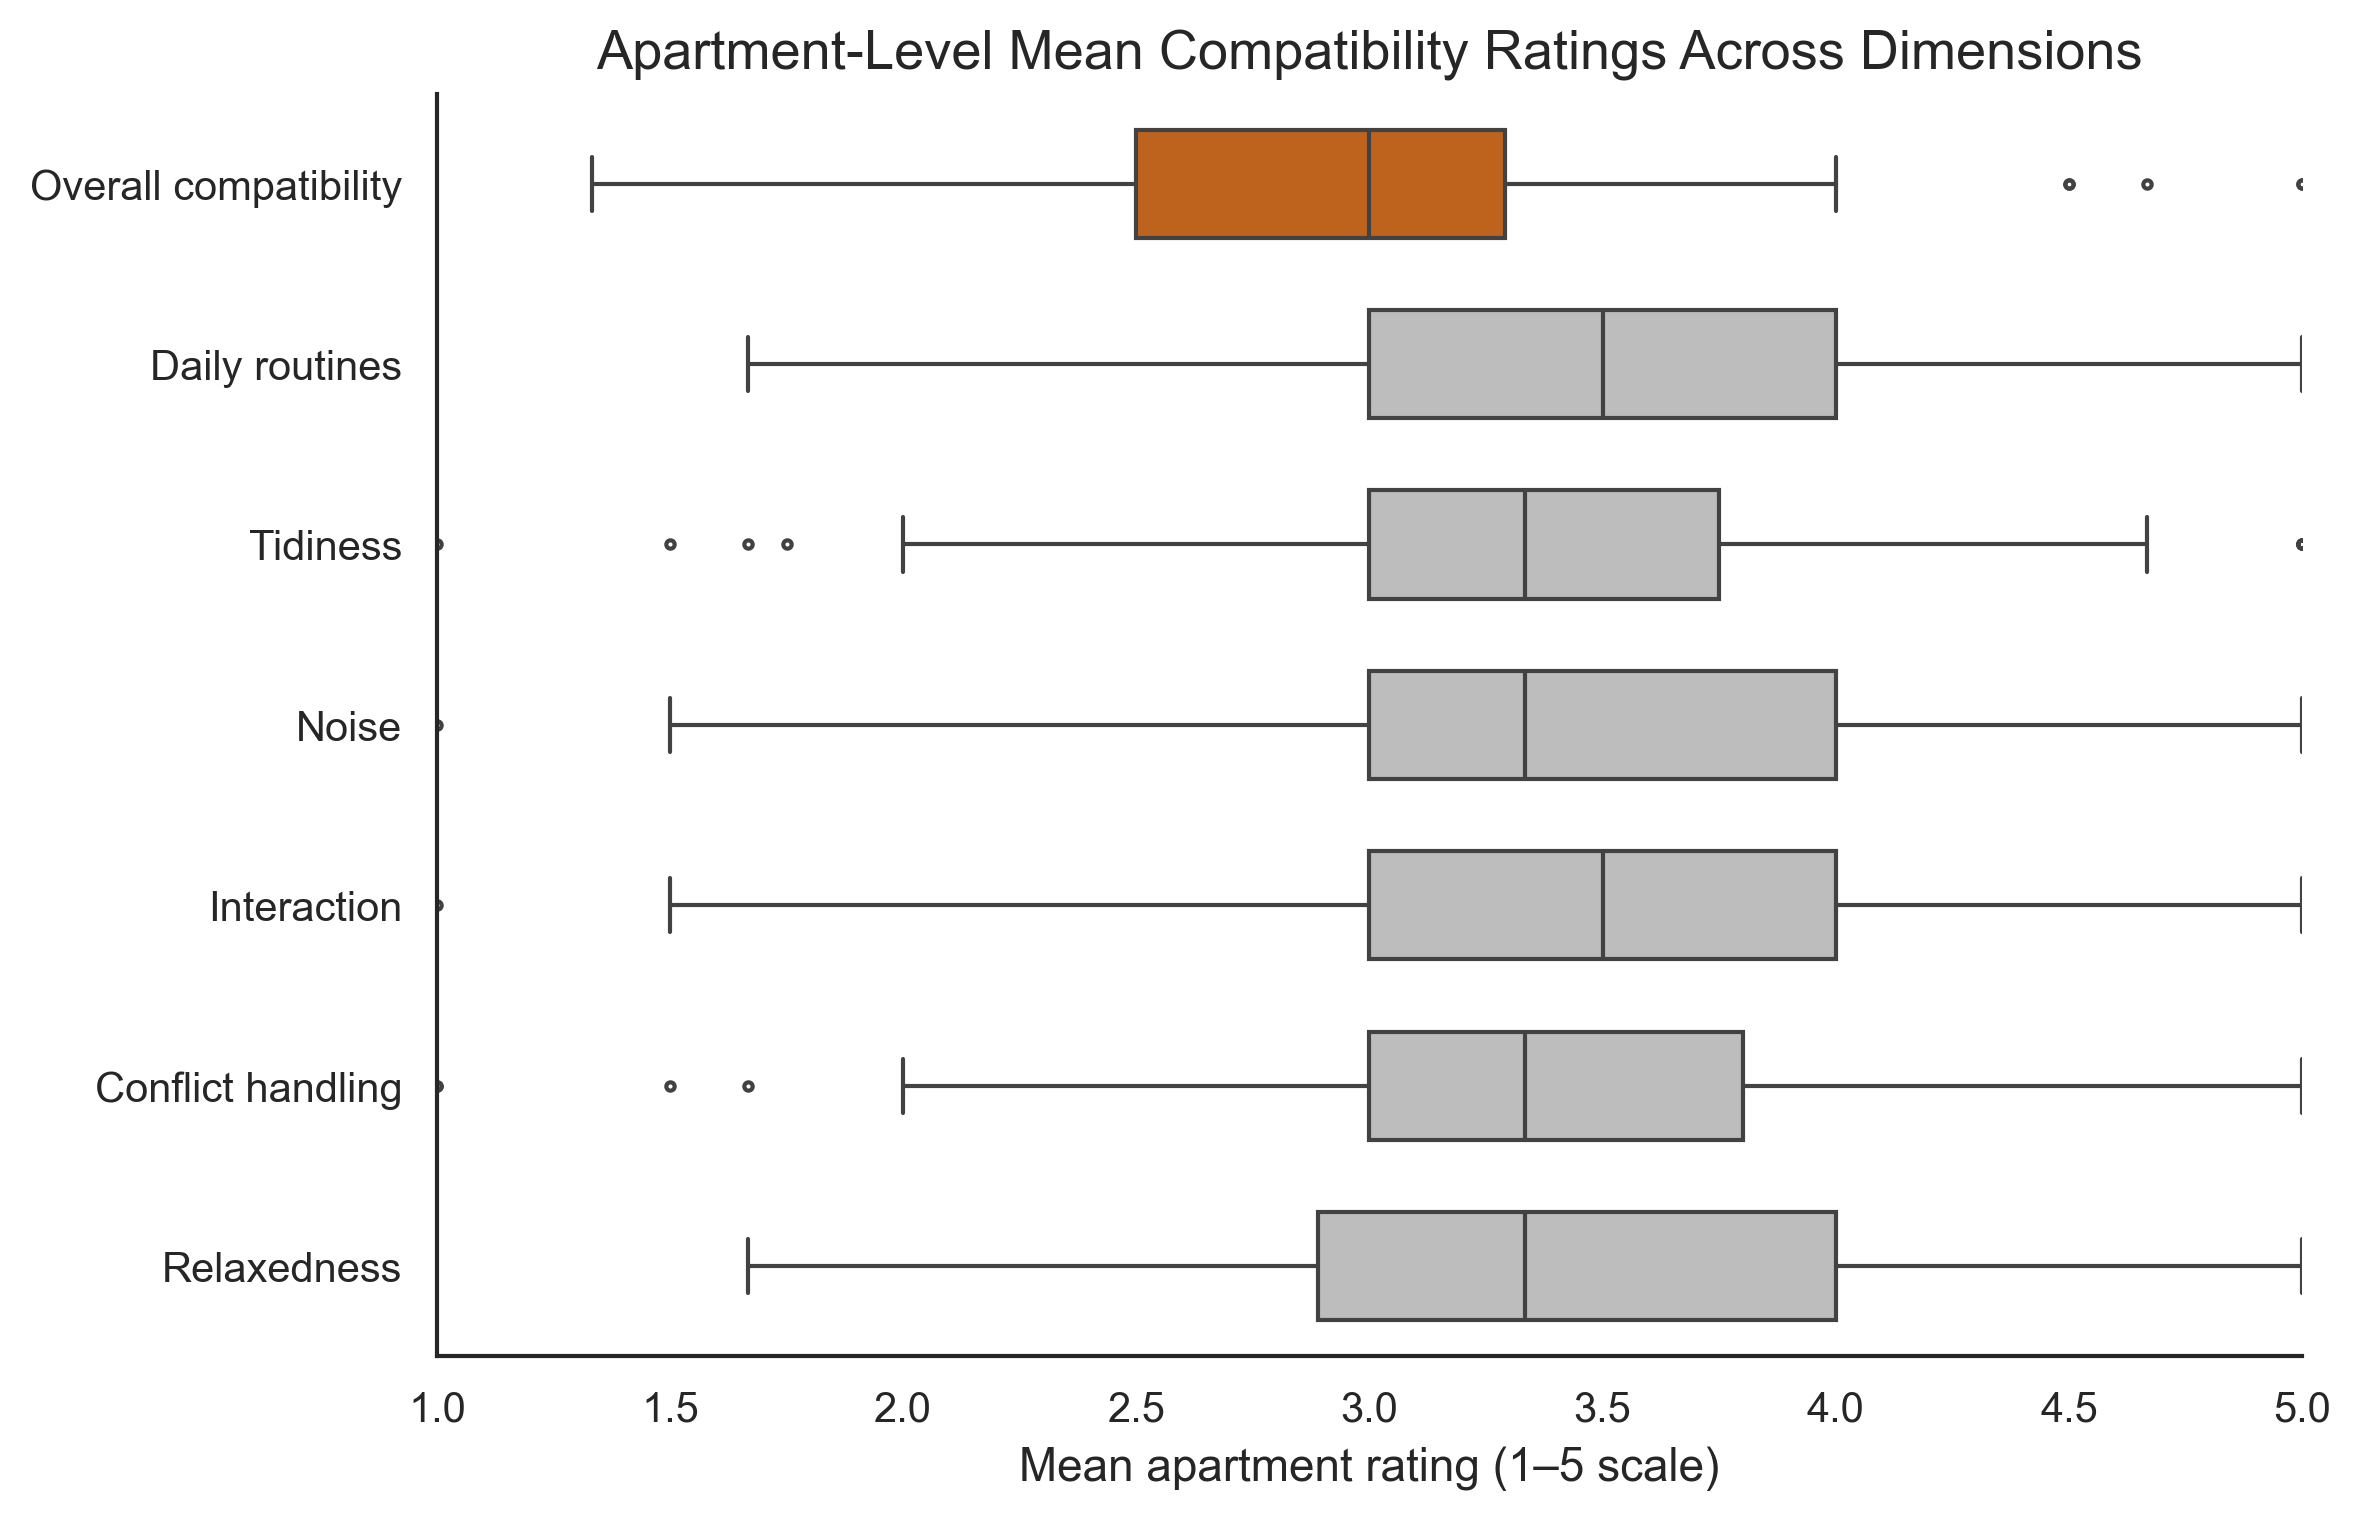

In [22]:
# ======================================
# Apartment-Level Perceived Compatibility (Mean by Dimension)
# ======================================

compat_cols_num = [
    "Compatibility_OverallRating_num",
    "Compat_DailyRoutines_num",
    "Compat_Tidiness_num",
    "Compat_Noise_num",
    "Compat_Interaction_num",
    "Compat_Conflict_num",
    "Compat_Relaxedness_num",
]

plot_df = merged_df[["Apartment"] + compat_cols_num].copy()

apt_means = (
    plot_df
    .groupby("Apartment", as_index=False)[compat_cols_num]
    .mean()
)

pretty_labels = {
    "Compatibility_OverallRating_num": "Overall compatibility",
    "Compat_DailyRoutines_num": "Daily routines",
    "Compat_Tidiness_num": "Tidiness",
    "Compat_Noise_num": "Noise",
    "Compat_Interaction_num": "Interaction",
    "Compat_Conflict_num": "Conflict handling",
    "Compat_Relaxedness_num": "Relaxedness",
}

long_df = apt_means.melt(
    id_vars="Apartment",
    var_name="Dimension",
    value_name="Rating"
).dropna(subset=["Rating"])

long_df["Dimension"] = long_df["Dimension"].replace(pretty_labels)

order = [pretty_labels[col] for col in compat_cols_num]

palette = {label: "#bdbdbd" for label in order}
palette["Overall compatibility"] = "#d95f02"

plt.figure(figsize=(8, 5.2), dpi=300)

sns.boxplot(
    data=long_df,
    x="Rating",
    y="Dimension",
    order=order,
    hue="Dimension",
    palette=palette,
    dodge=False,
    width=0.6,
    fliersize=2,
    linewidth=1,
    legend=False
)

plt.xlim(1, 5)
plt.xlabel("Mean apartment rating (1–5 scale)")
plt.ylabel("")
plt.title("Apartment-Level Mean Compatibility Ratings Across Dimensions")

sns.despine()
plt.tight_layout()
plt.show()

#### 2.7 Correlation Matrix for Numerical Variables

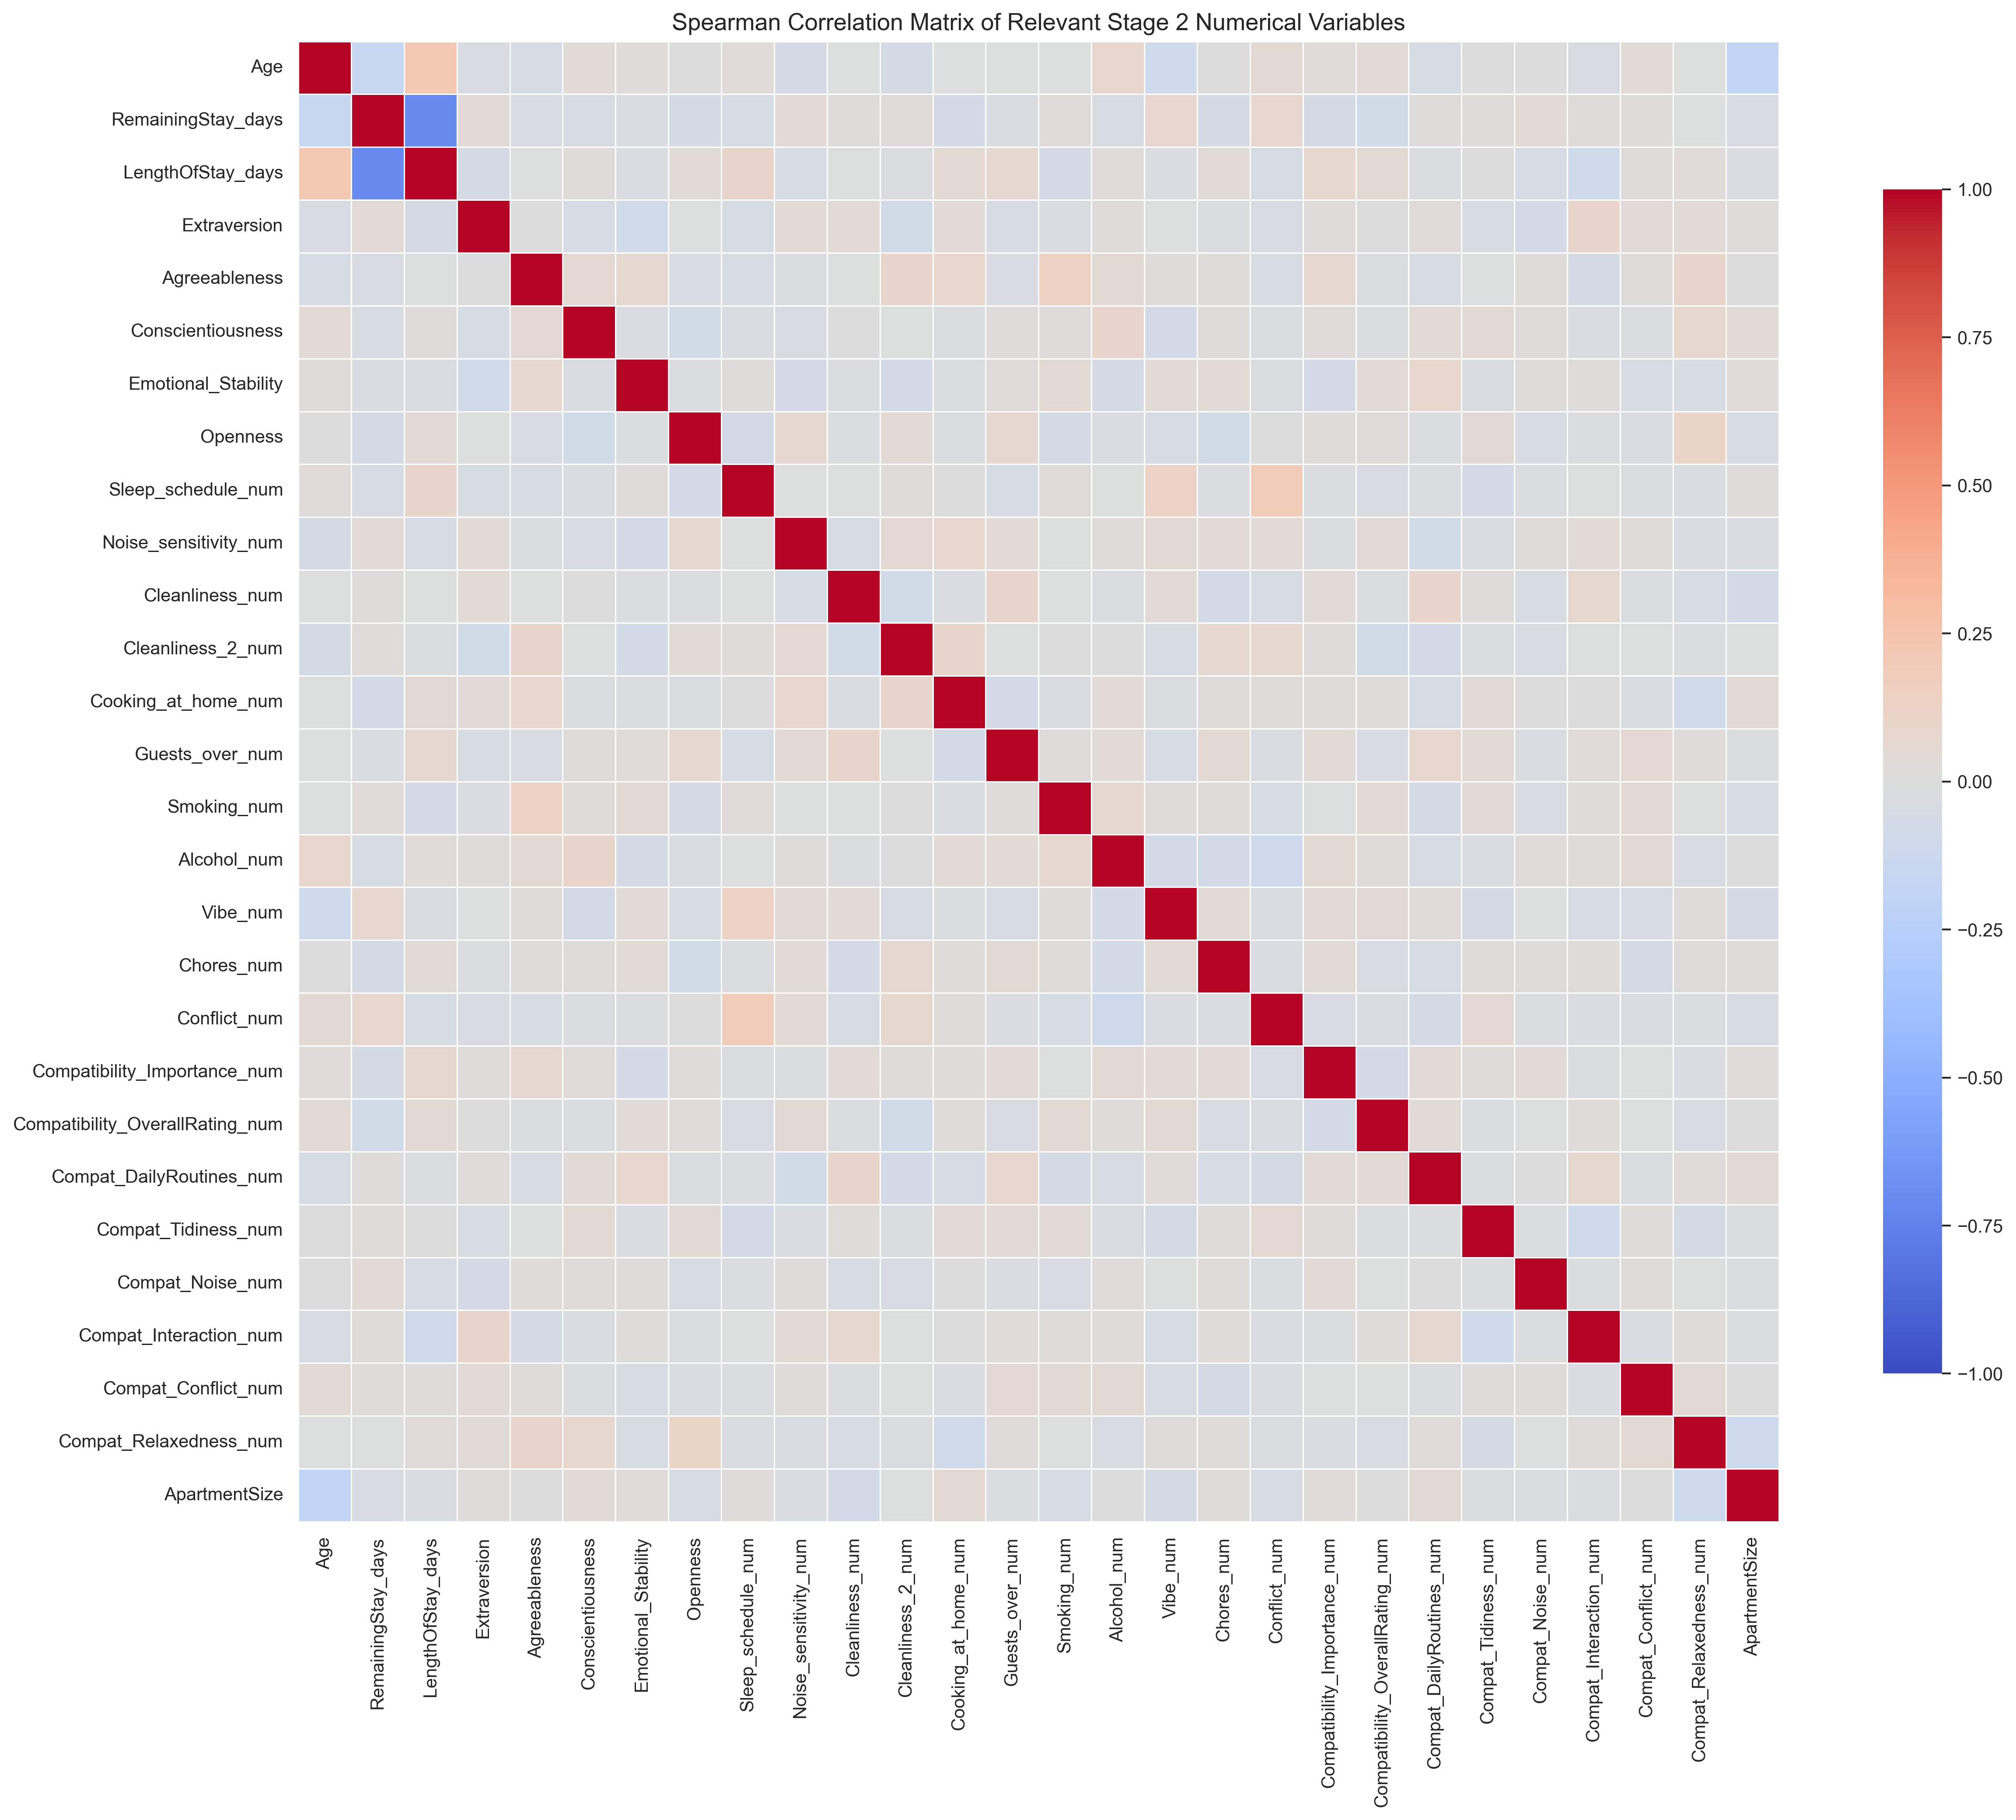

In [23]:
# ======================================
# Correlation Matrix for Relevant Stage 2 Numerical Variables
# ======================================

corr_cols = [
    "Age",
    "RemainingStay_days",
    "LengthOfStay_days",
    "Extraversion",
    "Agreeableness",
    "Conscientiousness",
    "Emotional_Stability",
    "Openness",
    "Sleep_schedule_num",
    "Noise_sensitivity_num",
    "Cleanliness_num",
    "Cleanliness_2_num",
    "Cooking_at_home_num",
    "Guests_over_num",
    "Smoking_num",
    "Alcohol_num",
    "Vibe_num",
    "Chores_num",
    "Conflict_num",
    "Compatibility_Importance_num",
    "Compatibility_OverallRating_num",
    "Compat_DailyRoutines_num",
    "Compat_Tidiness_num",
    "Compat_Noise_num",
    "Compat_Interaction_num",
    "Compat_Conflict_num",
    "Compat_Relaxedness_num",
    "ApartmentSize",
]

corr_df = merged_df[corr_cols].copy()

for col in corr_cols:
    corr_df[col] = pd.to_numeric(corr_df[col], errors="coerce")

corr_matrix = corr_df.corr(method="spearman")

plt.figure(figsize=(18, 14), dpi=300)

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8}
)

plt.title("Spearman Correlation Matrix of Relevant Stage 2 Numerical Variables")
plt.tight_layout()
plt.show()

### 3. Structural Compatibility Modeling

In [24]:
# ======================================
# Standardize column names to lowercase for consistency with stage 1 model and save for recommender input
# ======================================

# project root = parent of the notebooks folder
PROJECT_ROOT = Path.cwd().parent

output_path = PROJECT_ROOT / "data" / "processed" / "stage2_recommender_input.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)

merged_df.columns = [col.lower() for col in merged_df.columns]
merged_df.to_csv(output_path, index=False)

print(output_path.resolve())

/Users/user/thesis_coliving_compatibility/data/processed/stage2_recommender_input.csv


In [25]:
# ======================================
# Define Modeling Feature Groups
# ======================================

lifestyle_features = [
    "sleep_schedule_num",
    "noise_sensitivity_num",
    "vibe_num",
    "cleanliness_num",
    "guests_over_num",
    "alcohol_num",
    "smoking_num",
    "cooking_at_home_num",
    "chores_num",
]

excluded_lifestyle_features = [
    "cleanliness_2_num",
    "conflict_num",
]

priority_features = [
    "flatmatefactors_priority",
    "flatmatefactors_importance",
]

unit_features = [
    "unit",
    "apartment",
    "apartmentsize",
]

context_flag_features = [
    "gender",
    "nationality",
    "occupation",
    "remaining_stay",
    "age",
]

print("Lifestyle features:", lifestyle_features)
print("Excluded lifestyle features:", excluded_lifestyle_features)
print("Priority features:", priority_features)
print("Unit features:", unit_features)
print("Context flag features:", context_flag_features)

Lifestyle features: ['sleep_schedule_num', 'noise_sensitivity_num', 'vibe_num', 'cleanliness_num', 'guests_over_num', 'alcohol_num', 'smoking_num', 'cooking_at_home_num', 'chores_num']
Excluded lifestyle features: ['cleanliness_2_num', 'conflict_num']
Priority features: ['flatmatefactors_priority', 'flatmatefactors_importance']
Unit features: ['unit', 'apartment', 'apartmentsize']
Context flag features: ['gender', 'nationality', 'occupation', 'remaining_stay', 'age']


#### 3.1 Vacant Units for the Recommendation Engine

In [26]:
# ======================================
# Build Vacant Units from Apartment Size
# ======================================

vacant_units = []

for apt, group in merged_df.groupby("apartment"):
    size = int(group["apartmentsize"].iloc[0])

    existing_units = group["unit"].dropna().tolist()
    existing_numbers = [int(str(u).split(".")[-1]) for u in existing_units]

    full_range = set(range(1, size + 1))
    missing_numbers = sorted(full_range - set(existing_numbers))

    for num in missing_numbers:
        vacant_units.append({
            "apartment": apt,
            "vacant_unit": f"{apt}.{num}",
        })

vacant_units_df = pd.DataFrame(vacant_units)

print(f"Number of vacant units identified: {len(vacant_units_df)}")
vacant_units_df.head()

Number of vacant units identified: 47


,apartment,vacant_unit
0,PXA.07,PXA.07.1
1,PXA.13,PXA.13.1
2,PXA.16,PXA.16.1
3,PXA.17,PXA.17.3
4,PXA.23,PXA.23.1


#### 3.2 Layer 1: Personality Compatibility Matrix (Personalized)

In [27]:
# ======================================
# Build Personality Matrices for All Applicants
# ======================================

personality_matrices = build_personality_matrices(
    df_in=merged_df,
    profiles=PERSONALITY_PROFILES,
    id_col="unit",
)

print("Built personality matrices:", list(personality_matrices.keys()))

Built personality matrices: ['equal', 'harmony', 'reliability']


In [28]:
# ======================================
# Example: Get Personality Matrix for a Specific Applicant
# ======================================

applicant_unit = "PXA.01.2"

match = merged_df.loc[merged_df["unit"] == applicant_unit]

if match.empty:
    raise ValueError(f"Applicant unit '{applicant_unit}' not found in merged_df.")

applicant_row = match.iloc[0]

C_personality, selected_profile = get_applicant_personality_matrix(
    applicant_row=applicant_row,
    personality_matrices=personality_matrices,
    priority_col="flatmatefactors_priority",
)

print(f"Selected personality profile for {applicant_unit}: {selected_profile}")

Selected personality profile for PXA.01.2: harmony


In [29]:
# ======================================
# Personality Layer Sanity Check
# ======================================

print(f"Selected profile: {selected_profile}")
print(f"Matrix shape: {C_personality.shape}")
print(f"Applicant present in matrix: {applicant_unit in C_personality.index}")

# strongest pairwise personality matches for the selected applicant
applicant_scores = (
    C_personality.loc[applicant_unit]
    .drop(applicant_unit, errors="ignore")
    .sort_values(ascending=False)
)

applicant_scores.head(10)

Selected profile: harmony
Matrix shape: (563, 563)
Applicant present in matrix: True


unit
PXB.27.2    0.984649
PXC.05.2    0.969298
PXB.02.3    0.969298
PXA.32.3    0.967105
PXA.32.1    0.967105
PXB.25.2    0.967105
PXB.21.2    0.958333
PXC.22.4    0.956140
PXA.28.2    0.951754
PXA.33.3    0.951754
Name: PXA.01.2, dtype: float64

In [30]:
# ======================================
# Vacant Unit Sanity Check
# ======================================

print(f"Vacant apartments: {vacant_units_df['apartment'].nunique()}")
print(f"Vacant units: {len(vacant_units_df)}")

vacant_units_df.groupby("apartment").size().sort_values(ascending=False).head(10)

Vacant apartments: 40
Vacant units: 47


apartment
PXD.05    2
PXI.01    2
PXE.12    2
PXB.24    2
PXG.09    2
PXE.15    2
PXB.13    2
PXA.07    1
PXF.09    1
PXE.07    1
dtype: int64

In [31]:
# ======================================
# Apartment + Vacant Unit Personality Scores
# ======================================

def applicant_personality_unit_scores(
    applicant_unit: str,
    vacancy_df: pd.DataFrame,
    tenant_df: pd.DataFrame,
    C_personality: pd.DataFrame,
    apartment_col: str = "apartment",
    tenant_unit_col: str = "unit",
    vacancy_unit_col: str = "vacant_unit",
) -> pd.DataFrame:

    if applicant_unit not in C_personality.index:
        raise ValueError(f"Applicant unit '{applicant_unit}' not found in C_personality.")

    rows = []

    for _, vacant_row in vacancy_df.iterrows():
        vacant_unit = vacant_row[vacancy_unit_col]
        apt = vacant_row[apartment_col]

        residents = tenant_df.loc[
            tenant_df[apartment_col] == apt, tenant_unit_col
        ].dropna().tolist()

        residents = [u for u in residents if u != applicant_unit]
        residents = [u for u in residents if u in C_personality.columns]

        if not residents:
            continue

        pair_scores = C_personality.loc[applicant_unit, residents]

        rows.append({
            "vacant_unit": vacant_unit,
            "apartment": apt,
            "n_residents": len(residents),
            "mean_pair_personality": pair_scores.mean(),
            "min_pair_personality": pair_scores.min(),
            "max_pair_personality": pair_scores.max(),
            "std_pair_personality": pair_scores.std(),
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            by=["min_pair_personality", "mean_pair_personality"],
            ascending=False,
        )
        .reset_index(drop=True)
    )

In [32]:
# ======================================
# Compute Personality Scores for All Vacant Units
# ======================================

personality_unit_scores = applicant_personality_unit_scores(
    applicant_unit=applicant_unit,
    vacancy_df=vacant_units_df,
    tenant_df=merged_df,
    C_personality=C_personality,
    apartment_col="apartment",
    tenant_unit_col="unit",
    vacancy_unit_col="vacant_unit",
)

personality_unit_scores.head(10)

,vacant_unit,apartment,n_residents,mean_pair_personality,min_pair_personality,max_pair_personality,std_pair_personality
0,PXB.13.1,PXB.13,2,0.890351,0.877193,0.903509,0.018608
1,PXB.13.2,PXB.13,2,0.890351,0.877193,0.903509,0.018608
2,PXC.04.1,PXC.04,1,0.861842,0.861842,0.861842,NaN
3,PXA.38.2,PXA.38,3,0.833333,0.822368,0.844298,0.010965
4,PXB.14.3,PXB.14,3,0.831140,0.815789,0.850877,0.017950
5,PXA.13.1,PXA.13,1,0.815789,0.815789,0.815789,NaN
6,PXA.17.3,PXA.17,3,0.836257,0.811404,0.875000,0.033997
7,PXB.27.1,PXB.27,2,0.893640,0.802632,0.984649,0.128706
8,PXB.08.4,PXB.08,4,0.837171,0.800439,0.881579,0.037103
9,PXJ.02.1,PXJ.02,1,0.800439,0.800439,0.800439,NaN


#### 3.3 Layer 2: Lifestyle Compatibility Matrix

In [33]:
# ======================================
# Lifestyle Design Matrix
# ======================================

X_lifestyle = merged_df[["unit", "apartment"] + lifestyle_features].copy()

print(f"X_lifestyle shape: {X_lifestyle.shape}")
print("Missing values per lifestyle feature:")
print(X_lifestyle[lifestyle_features].isna().sum().sort_values(ascending=False))

X_lifestyle shape: (563, 11)
Missing values per lifestyle feature:
sleep_schedule_num       0
noise_sensitivity_num    0
vibe_num                 0
cleanliness_num          0
guests_over_num          0
alcohol_num              0
smoking_num              0
cooking_at_home_num      0
chores_num               0
dtype: int64


In [34]:
# ======================================
# Feature Ranges for Mixed Lifestyle Scales
# ======================================

def build_feature_ranges(df_in: pd.DataFrame, feature_cols: list[str]) -> dict:
    """
    Build observed min/max ranges for each lifestyle feature.
    This allows mixed scales (e.g. 1-4, 1-5, binary).
    """
    ranges = {}

    for col in feature_cols:
        col_min = float(df_in[col].min())
        col_max = float(df_in[col].max())

        if col_max <= col_min:
            raise ValueError(
                f"Feature '{col}' has no usable range: min={col_min}, max={col_max}"
            )

        ranges[col] = {
            "min": col_min,
            "max": col_max,
            "span": col_max - col_min,
        }

    return ranges


lifestyle_feature_ranges = build_feature_ranges(
    df_in=merged_df,
    feature_cols=lifestyle_features,
)

pd.DataFrame(lifestyle_feature_ranges).T

,min,max,span
sleep_schedule_num,1.0,4.0,3.0
noise_sensitivity_num,1.0,5.0,4.0
vibe_num,1.0,5.0,4.0
cleanliness_num,1.0,5.0,4.0
guests_over_num,1.0,5.0,4.0
alcohol_num,1.0,5.0,4.0
smoking_num,0.0,1.0,1.0
cooking_at_home_num,1.0,5.0,4.0
chores_num,1.0,5.0,4.0


In [35]:
# ======================================
# Feature Ranges for Mixed Lifestyle Scales
# ======================================

THEORETICAL_FEATURE_RANGES = {
    "sleep_schedule_num": {"min": 1.0, "max": 4.0},
    "noise_sensitivity_num": {"min": 1.0, "max": 5.0},
    "vibe_num": {"min": 1.0, "max": 5.0},
    "cleanliness_num": {"min": 1.0, "max": 5.0},
    "guests_over_num": {"min": 1.0, "max": 5.0},
    "alcohol_num": {"min": 1.0, "max": 5.0},
    "smoking_num": {"min": 0.0, "max": 1.0},
    "cooking_at_home_num": {"min": 1.0, "max": 5.0},
    "chores_num": {"min": 1.0, "max": 5.0},
}

def build_feature_ranges(feature_cols: list[str]) -> dict:
    """
    Build theoretical min/max ranges for each lifestyle feature
    using the full coded scale rather than the observed sample range.
    """
    ranges = {}

    for col in feature_cols:
        if col not in THEORETICAL_FEATURE_RANGES:
            raise KeyError(f"No theoretical range defined for feature '{col}'")

        col_min = float(THEORETICAL_FEATURE_RANGES[col]["min"])
        col_max = float(THEORETICAL_FEATURE_RANGES[col]["max"])

        if col_max <= col_min:
            raise ValueError(
                f"Feature '{col}' has invalid theoretical range: min={col_min}, max={col_max}"
            )

        ranges[col] = {
            "min": col_min,
            "max": col_max,
            "span": col_max - col_min,
        }

    return ranges


lifestyle_feature_ranges = build_feature_ranges(lifestyle_features)

pd.DataFrame(lifestyle_feature_ranges).T

,min,max,span
sleep_schedule_num,1.0,4.0,3.0
noise_sensitivity_num,1.0,5.0,4.0
vibe_num,1.0,5.0,4.0
cleanliness_num,1.0,5.0,4.0
guests_over_num,1.0,5.0,4.0
alcohol_num,1.0,5.0,4.0
smoking_num,0.0,1.0,1.0
cooking_at_home_num,1.0,5.0,4.0
chores_num,1.0,5.0,4.0


In [36]:
# ======================================
# Lifestyle Similarity Component
# ======================================

def lifestyle_similarity_component(a: float, b: float, span: float) -> float:
    """
    Convert absolute difference into similarity in [0, 1]
    using the full coded range of the feature.
    """
    return float(np.clip(1.0 - (abs(a - b) / span), 0.0, 1.0))

In [37]:
# ======================================
# Pairwise Lifestyle Compatibility
# ======================================

def lifestyle_compatibility_between_rows(
    row_i: pd.Series,
    row_j: pd.Series,
    *,
    feature_cols: list[str],
    feature_ranges: dict,
    weights: dict | None = None,
) -> float:
    """
    Compute a weighted all-similarity lifestyle score between two rows.
    """
    if weights is None:
        weights = {f: 1.0 for f in feature_cols}

    num = 0.0
    den = 0.0

    for f in feature_cols:
        w = float(weights.get(f, 1.0))
        span = float(feature_ranges[f]["span"])

        s = lifestyle_similarity_component(
            row_i[f],
            row_j[f],
            span=span,
        )

        num += w * s
        den += w

    return num / den if den else np.nan

In [38]:
# ======================================
# Lifestyle Compatibility Matrix
# ======================================

def lifestyle_compatibility_matrix(
    df_in: pd.DataFrame,
    *,
    feature_cols: list[str],
    feature_ranges: dict,
    weights: dict | None = None,
    id_col: str = "unit",
) -> pd.DataFrame:
    """
    Build symmetric pairwise lifestyle compatibility matrix.
    """
    work_df = df_in.copy()

    if id_col in work_df.columns:
        if work_df[id_col].duplicated().any():
            raise ValueError(f"Column '{id_col}' contains duplicate IDs.")
        work_df = work_df.set_index(id_col, drop=False)

    n = len(work_df)
    M = np.eye(n, dtype=float)

    for i in range(n):
        for j in range(i + 1, n):
            s = lifestyle_compatibility_between_rows(
                work_df.iloc[i],
                work_df.iloc[j],
                feature_cols=feature_cols,
                feature_ranges=feature_ranges,
                weights=weights,
            )
            M[i, j] = s
            M[j, i] = s

    return pd.DataFrame(M, index=work_df.index, columns=work_df.index)

In [39]:
# ======================================
# Build Lifestyle Matrix
# ======================================

LIFESTYLE_WEIGHTS = {f: 1.0 for f in lifestyle_features}

C_lifestyle = lifestyle_compatibility_matrix(
    df_in=merged_df,
    feature_cols=lifestyle_features,
    feature_ranges=lifestyle_feature_ranges,
    weights=LIFESTYLE_WEIGHTS,
    id_col="unit",
)

print(f"Lifestyle matrix shape: {C_lifestyle.shape}")
C_lifestyle.iloc[:5, :5]

Lifestyle matrix shape: (563, 563)


unit,PXA.01.2,PXA.01.1,PXA.02.2,PXA.02.1,PXA.03.3
unit,,,,,
PXA.01.2,1.000000,0.768519,0.851852,0.731481,0.657407
PXA.01.1,0.768519,1.000000,0.750000,0.629630,0.777778
PXA.02.2,0.851852,0.750000,1.000000,0.768519,0.694444
PXA.02.1,0.731481,0.629630,0.768519,1.000000,0.629630
PXA.03.3,0.657407,0.777778,0.694444,0.629630,1.000000


In [40]:
# ======================================
# Lifestyle Layer Sanity Check
# ======================================

print(f"Applicant present in lifestyle matrix: {applicant_unit in C_lifestyle.index}")

applicant_lifestyle_scores = (
    C_lifestyle.loc[applicant_unit]
    .drop(applicant_unit, errors="ignore")
    .sort_values(ascending=False)
)

applicant_lifestyle_scores.head(10)

Applicant present in lifestyle matrix: True


unit
PXC.03.2    0.944444
PXC.24.1    0.916667
PXH.02.2    0.916667
PXI.04.1    0.916667
PXG.06.3    0.888889
PXG.04.1    0.888889
PXF.06.4    0.879630
PXD.08.2    0.879630
PXB.21.4    0.870370
PXA.22.2    0.870370
Name: PXA.01.2, dtype: float64

In [41]:
# ======================================
# Apartment + Vacant Unit Lifestyle Scores
# ======================================

def applicant_lifestyle_unit_scores(
    applicant_unit: str,
    vacancy_df: pd.DataFrame,
    tenant_df: pd.DataFrame,
    C_lifestyle: pd.DataFrame,
    apartment_col: str = "apartment",
    tenant_unit_col: str = "unit",
    vacancy_unit_col: str = "vacant_unit",
) -> pd.DataFrame:

    if applicant_unit not in C_lifestyle.index:
        raise ValueError(f"Applicant unit '{applicant_unit}' not found in C_lifestyle.")

    rows = []

    for _, vacant_row in vacancy_df.iterrows():
        vacant_unit = vacant_row[vacancy_unit_col]
        apt = vacant_row[apartment_col]

        residents = tenant_df.loc[
            tenant_df[apartment_col] == apt, tenant_unit_col
        ].dropna().tolist()

        residents = [u for u in residents if u != applicant_unit]
        residents = [u for u in residents if u in C_lifestyle.columns]

        if not residents:
            continue

        pair_scores = C_lifestyle.loc[applicant_unit, residents]

        rows.append({
            "vacant_unit": vacant_unit,
            "apartment": apt,
            "n_residents": len(residents),
            "mean_pair_lifestyle": pair_scores.mean(),
            "min_pair_lifestyle": pair_scores.min(),
            "max_pair_lifestyle": pair_scores.max(),
            "std_pair_lifestyle": pair_scores.std(),
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            by=["min_pair_lifestyle", "mean_pair_lifestyle"],
            ascending=False,
        )
        .reset_index(drop=True)
    )

In [42]:
# ======================================
# Compute Lifestyle Scores for All Vacant Units
# ======================================

lifestyle_unit_scores = applicant_lifestyle_unit_scores(
    applicant_unit=applicant_unit,
    vacancy_df=vacant_units_df,
    tenant_df=merged_df,
    C_lifestyle=C_lifestyle,
    apartment_col="apartment",
    tenant_unit_col="unit",
    vacancy_unit_col="vacant_unit",
)

lifestyle_unit_scores.head(10)

,vacant_unit,apartment,n_residents,mean_pair_lifestyle,min_pair_lifestyle,max_pair_lifestyle,std_pair_lifestyle
0,PXC.04.1,PXC.04,1,0.759259,0.759259,0.759259,NaN
1,PXG.12.2,PXG.12,4,0.773148,0.740741,0.851852,0.053190
2,PXA.37.2,PXA.37,2,0.754630,0.731481,0.777778,0.032736
3,PXC.10.2,PXC.10,2,0.726852,0.722222,0.731481,0.006547
4,PXA.13.1,PXA.13,1,0.722222,0.722222,0.722222,NaN
5,PXB.27.1,PXB.27,2,0.722222,0.712963,0.731481,0.013095
6,PXE.15.1,PXE.15,2,0.777778,0.703704,0.851852,0.104757
7,PXE.15.3,PXE.15,2,0.777778,0.703704,0.851852,0.104757
8,PXG.10.1,PXG.10,3,0.740741,0.685185,0.814815,0.066769
9,PXA.29.1,PXA.29,3,0.722222,0.685185,0.777778,0.048995


#### 3.4 Combined Applicant-Personalized Compatibility Layer

In [43]:
# ======================================
# Applicant-Specific Layer Weights
# ======================================

def get_layer_weights(
    importance_value: float,
    observed_min: float,
    observed_max: float,
    min_personality_weight: float = 0.40,
    max_personality_weight: float = 0.70,
) -> dict:
    """
    Map compatibility importance to personality and lifestyle layer weights.

    Lower importance  -> more balanced / more lifestyle influence
    Higher importance -> more personality influence
    """
    if observed_max <= observed_min:
        p_weight = 0.55
    else:
        x = (float(importance_value) - observed_min) / (observed_max - observed_min)
        x = float(np.clip(x, 0.0, 1.0))
        p_weight = min_personality_weight + x * (
            max_personality_weight - min_personality_weight
        )

    l_weight = 1.0 - p_weight

    return {
        "personality_weight": p_weight,
        "lifestyle_weight": l_weight,
    }


importance_min = float(merged_df["compatibility_importance_num"].min())
importance_max = float(merged_df["compatibility_importance_num"].max())

layer_weights = get_layer_weights(
    importance_value=applicant_row["compatibility_importance_num"],
    observed_min=importance_min,
    observed_max=importance_max,
)

print(f"Selected profile: {selected_profile}")
print(f"Layer weights: {layer_weights}")

Selected profile: harmony
Layer weights: {'personality_weight': 0.55, 'lifestyle_weight': 0.44999999999999996}


In [44]:
# ======================================
# Applicant-Conditioned Final Pairwise Matrix
# ======================================

def build_final_pairwise_matrix(
    C_personality: pd.DataFrame,
    C_lifestyle: pd.DataFrame,
    personality_weight: float,
    lifestyle_weight: float,
) -> pd.DataFrame:
    """
    Weighted combination of personality and lifestyle matrices.
    """
    return (
        personality_weight * C_personality
        + lifestyle_weight * C_lifestyle
    )


C_final = build_final_pairwise_matrix(
    C_personality=C_personality,
    C_lifestyle=C_lifestyle,
    personality_weight=layer_weights["personality_weight"],
    lifestyle_weight=layer_weights["lifestyle_weight"],
)

print("Final matrix shape:", C_final.shape)
C_final.iloc[:5, :5]

Final matrix shape: (563, 563)


unit,PXA.01.2,PXA.01.1,PXA.02.2,PXA.02.1,PXA.03.3
unit,,,,,
PXA.01.2,1.000000,0.783662,0.829605,0.730811,0.709539
PXA.01.1,0.783662,1.000000,0.842873,0.760965,0.839693
PXA.02.2,0.829605,0.842873,1.000000,0.815022,0.793750
PXA.02.1,0.730811,0.760965,0.815022,1.000000,0.792325
PXA.03.3,0.709539,0.839693,0.793750,0.792325,1.000000


In [45]:
# ======================================
# Final Pairwise Layer Sanity Check
# ======================================

applicant_final_scores = (
    C_final.loc[applicant_unit]
    .drop(applicant_unit, errors="ignore")
    .sort_values(ascending=False)
)

applicant_final_scores.head(10)

unit
PXG.04.1    0.887281
PXC.05.2    0.883114
PXG.12.4    0.877851
PXI.04.1    0.876864
PXJ.05.1    0.876096
PXB.12.5    0.874232
PXG.02.2    0.871491
PXD.04.3    0.871162
PXB.27.2    0.870724
PXC.24.1    0.867215
Name: PXA.01.2, dtype: float64

#### 3.5 Coalition Utility Function

In [46]:
# ======================================
# Coalition Utility Functions
# ======================================

def coalition_member_utilities(submatrix: pd.DataFrame) -> pd.Series:
    """
    Utility of each member = mean compatibility to all other members.
    """
    utilities = {}

    for member in submatrix.index:
        others = submatrix.columns[submatrix.columns != member]

        if len(others) == 0:
            utilities[member] = np.nan
        else:
            utilities[member] = submatrix.loc[member, others].mean()

    return pd.Series(utilities)


def coalition_metrics(submatrix: pd.DataFrame) -> dict:
    """
    Compute apartment-level structural metrics for a coalition.
    """
    utilities = coalition_member_utilities(submatrix)
    pair_values = upper_triangle_values(submatrix)

    return {
        "harmony": float(utilities.mean()),
        "fairness": float(utilities.min()),
        "min_pair": float(pair_values.min()) if len(pair_values) > 0 else np.nan,
        "mean_pair": float(pair_values.mean()) if len(pair_values) > 0 else np.nan,
        "max_pair": float(pair_values.max()) if len(pair_values) > 0 else np.nan,
        "utility_std": float(utilities.std()),
    }

In [47]:
# ======================================
# Vacancy-Level Structural Scoring
# ======================================

def applicant_vacancy_structural_scores(
    applicant_unit: str,
    vacancy_df: pd.DataFrame,
    tenant_df: pd.DataFrame,
    C_final: pd.DataFrame,
    apartment_col: str = "apartment",
    tenant_unit_col: str = "unit",
    vacancy_unit_col: str = "vacant_unit",
) -> pd.DataFrame:

    if applicant_unit not in C_final.index:
        raise ValueError(f"Applicant unit '{applicant_unit}' not found in C_final.")

    rows = []

    for _, vacant_row in vacancy_df.iterrows():
        vacant_unit = vacant_row[vacancy_unit_col]
        apt = vacant_row[apartment_col]

        residents = tenant_df.loc[
            tenant_df[apartment_col] == apt, tenant_unit_col
        ].dropna().tolist()

        residents = [u for u in residents if u != applicant_unit]
        residents = [u for u in residents if u in C_final.index]

        if not residents:
            continue

        coalition_units = residents + [applicant_unit]
        submatrix = C_final.loc[coalition_units, coalition_units]

        metrics = coalition_metrics(submatrix)

        rows.append({
            "vacant_unit": vacant_unit,
            "apartment": apt,
            "n_residents": len(residents),
            "harmony": metrics["harmony"],
            "fairness": metrics["fairness"],
            "min_pair": metrics["min_pair"],
            "mean_pair": metrics["mean_pair"],
            "max_pair": metrics["max_pair"],
            "utility_std": metrics["utility_std"],
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            by=["fairness", "harmony", "min_pair"],
            ascending=False,
        )
        .reset_index(drop=True)
    )

In [48]:
# ======================================
# Compute Structural Vacancy Scores
# ======================================

structural_scores_df = applicant_vacancy_structural_scores(
    applicant_unit=applicant_unit,
    vacancy_df=vacant_units_df,
    tenant_df=merged_df,
    C_final=C_final,
    apartment_col="apartment",
    tenant_unit_col="unit",
    vacancy_unit_col="vacant_unit",
)

structural_scores_df.head(10)

,vacant_unit,apartment,n_residents,harmony,fairness,min_pair,mean_pair,max_pair,utility_std
0,PXC.04.1,PXC.04,1,0.815680,0.815680,0.815680,0.815680,0.815680,0.000000
1,PXE.15.1,PXE.15,2,0.814839,0.794463,0.747259,0.814839,0.855592,0.029470
2,PXE.15.3,PXE.15,2,0.814839,0.794463,0.747259,0.814839,0.855592,0.029470
3,PXG.09.1,PXG.09,3,0.804112,0.790972,0.766776,0.804112,0.862719,0.012143
4,PXG.09.4,PXG.09,3,0.804112,0.790972,0.766776,0.804112,0.862719,0.012143
5,PXB.08.4,PXB.08,4,0.816404,0.790652,0.739145,0.816404,0.898465,0.019757
6,PXB.13.1,PXB.13,2,0.804020,0.785526,0.782456,0.804020,0.841009,0.016090
7,PXB.13.2,PXB.13,2,0.804020,0.785526,0.782456,0.804020,0.841009,0.016090
8,PXB.27.1,PXB.27,2,0.813743,0.785252,0.762281,0.813743,0.870724,0.027216
9,PXG.12.2,PXG.12,4,0.808531,0.775356,0.736184,0.808531,0.877851,0.021639


In [49]:
# ======================================
# Final Structural Score
# ======================================

def add_structural_score(
    df_in: pd.DataFrame,
    w_fairness: float = 0.45,
    w_harmony: float = 0.35,
    w_min_pair: float = 0.20,
) -> pd.DataFrame:
    """
    Compute a weighted structural score for ranking candidate vacancies.
    """
    out = df_in.copy()

    out["struct_score"] = (
        w_fairness * out["fairness"]
        + w_harmony * out["harmony"]
        + w_min_pair * out["min_pair"]
    )

    return (
        out.sort_values(
            by=["struct_score", "fairness", "harmony"],
            ascending=False,
        )
        .reset_index(drop=True)
    )


recs_df = add_structural_score(structural_scores_df)

recs_df.head(10)

,vacant_unit,apartment,n_residents,harmony,fairness,min_pair,mean_pair,max_pair,utility_std,struct_score
0,PXC.04.1,PXC.04,1,0.815680,0.815680,0.815680,0.815680,0.815680,0.000000,0.815680
1,PXE.15.1,PXE.15,2,0.814839,0.794463,0.747259,0.814839,0.855592,0.029470,0.792154
2,PXE.15.3,PXE.15,2,0.814839,0.794463,0.747259,0.814839,0.855592,0.029470,0.792154
3,PXB.13.1,PXB.13,2,0.804020,0.785526,0.782456,0.804020,0.841009,0.016090,0.791385
4,PXB.13.2,PXB.13,2,0.804020,0.785526,0.782456,0.804020,0.841009,0.016090,0.791385
5,PXG.09.1,PXG.09,3,0.804112,0.790972,0.766776,0.804112,0.862719,0.012143,0.790732
6,PXG.09.4,PXG.09,3,0.804112,0.790972,0.766776,0.804112,0.862719,0.012143,0.790732
7,PXB.27.1,PXB.27,2,0.813743,0.785252,0.762281,0.813743,0.870724,0.027216,0.790630
8,PXB.08.4,PXB.08,4,0.816404,0.790652,0.739145,0.816404,0.898465,0.019757,0.789364
9,PXG.12.2,PXG.12,4,0.808531,0.775356,0.736184,0.808531,0.877851,0.021639,0.779133


#### 3.6 Layer 3: Context Flags

In [50]:
# ======================================
# Helper Functions for Flags
# ======================================

def normalize_flag_value(x):
    """
    Normalize values for robust comparison in flags.
    """
    if pd.isna(x):
        return None
    return str(x).strip().lower()


def homogeneous_mismatch_flag(
    resident_values,
    applicant_value,
    min_residents: int = 2,
) -> bool:
    """
    Flag if residents are homogeneous on a category and differ from applicant.
    """
    vals = [normalize_flag_value(v) for v in resident_values]
    vals = [v for v in vals if v is not None]

    applicant = normalize_flag_value(applicant_value)

    if applicant is None:
        return False

    if len(vals) < min_residents:
        return False

    uniq = set(vals)

    return (len(uniq) == 1) and (next(iter(uniq)) != applicant)

In [51]:
# ======================================
# Helper Functions for Flags
# ======================================

def normalize_flag_value(x):
    """
    Normalize values for robust comparison in flags.
    """
    if pd.isna(x):
        return None
    return str(x).strip().lower()


def is_unknown_flag_value(x) -> bool:
    """
    Treat missing-like categorical values as unknown for flag logic.
    """
    x_norm = normalize_flag_value(x)
    return x_norm in {None, "", "unknown", "prefer not to say", "not specified", "na", "n/a"}


def get_homogeneous_group_label(resident_values, min_residents: int = 2):
    """
    Return the shared category label if all known resident values are the same.
    Otherwise return None.
    """
    vals = [normalize_flag_value(v) for v in resident_values]
    vals = [v for v in vals if not is_unknown_flag_value(v)]

    if len(vals) < min_residents:
        return None

    uniq = set(vals)

    if len(uniq) == 1:
        return next(iter(uniq))

    return None


# ======================================
# Vacancy-Level Flags
# ======================================

def applicant_vacancy_flags(
    applicant_unit: str,
    vacancy_df: pd.DataFrame,
    tenant_df: pd.DataFrame,
    apartment_col: str = "apartment",
    tenant_unit_col: str = "unit",
    vacancy_unit_col: str = "vacant_unit",
    age_col: str = "age",
    gender_col: str = "gender",
    nationality_col: str = "nationality",
    occupation_col: str = "occupation",
    remainingstay_col: str = "remainingstay_days",
    age_window: float = 5.0,
    turnover_threshold: float = 30.0,
    turnover_share_threshold: float = 0.5,
) -> pd.DataFrame:

    rows = []

    applicant_match = tenant_df.loc[tenant_df[tenant_unit_col] == applicant_unit]
    if applicant_match.empty:
        raise ValueError(f"Applicant unit '{applicant_unit}' not found in tenant_df.")

    applicant_row = applicant_match.iloc[0]
    applicant_age = float(applicant_row[age_col])

    for _, vacant_row in vacancy_df.iterrows():
        vacant_unit = vacant_row[vacancy_unit_col]
        apt = vacant_row[apartment_col]

        residents_df = tenant_df.loc[tenant_df[apartment_col] == apt].copy()
        residents_df = residents_df.loc[residents_df[tenant_unit_col] != applicant_unit]

        n_residents = len(residents_df)

        if n_residents == 0:
            continue

        # ---- Homogeneous apartment composition flags ----
        gender_group = get_homogeneous_group_label(
            resident_values=residents_df[gender_col].tolist(),
            min_residents=2,
        )
        nationality_group = get_homogeneous_group_label(
            resident_values=residents_df[nationality_col].tolist(),
            min_residents=2,
        )
        occupation_group = get_homogeneous_group_label(
            resident_values=residents_df[occupation_col].tolist(),
            min_residents=2,
        )

        flag_gender_homogeneous = gender_group is not None
        flag_nationality_homogeneous = nationality_group is not None
        flag_occupation_homogeneous = occupation_group is not None

        # ---- Age proximity flag ----
        resident_ages = residents_df[age_col].dropna()
        age_gap_flag = True
        if not resident_ages.empty:
            age_diffs = (resident_ages - applicant_age).abs()
            age_gap_flag = bool((age_diffs > age_window).all())

        # ---- Turnover risk flag ----
        known_remaining = residents_df[remainingstay_col].dropna()
        if known_remaining.empty:
            turnover_flag = False
            turnover_share = np.nan
        else:
            turnover_share = float((known_remaining < turnover_threshold).mean())
            turnover_flag = bool(turnover_share >= turnover_share_threshold)

        rows.append({
            "vacant_unit": vacant_unit,
            "apartment": apt,
            "n_residents": n_residents,
            "flag_age_gap": age_gap_flag,
            "flag_high_turnover": turnover_flag,
            "turnover_share_lt_threshold": turnover_share,
            "flag_gender_homogeneous": flag_gender_homogeneous,
            "gender_group": gender_group,
            "flag_nationality_homogeneous": flag_nationality_homogeneous,
            "nationality_group": nationality_group,
            "flag_occupation_homogeneous": flag_occupation_homogeneous,
            "occupation_group": occupation_group,
        })

    return pd.DataFrame(rows)

In [52]:
# ======================================
# Notes Column from Flags
# ======================================

def build_flag_notes(df_in: pd.DataFrame) -> pd.DataFrame:
    out = df_in.copy()

    def row_notes(row):
        notes = []

        if row["flag_gender_homogeneous"]:
            notes.append(f"Gender homogeneous: {row['gender_group']}")

        if row["flag_age_gap"]:
            notes.append("No resident within ±5 years")

        if row["flag_nationality_homogeneous"]:
            notes.append(f"Nationality homogeneous: {row['nationality_group']}")

        if row["flag_occupation_homogeneous"]:
            notes.append(f"Occupation homogeneous: {row['occupation_group']}")

        if row["flag_high_turnover"]:
            notes.append("High turnover risk")

        return " | ".join(notes)

    out["notes"] = out.apply(row_notes, axis=1)

    return out

In [53]:
# ======================================
# Compute Vacancy Flags
# ======================================

flags_df = applicant_vacancy_flags(
    applicant_unit=applicant_unit,
    vacancy_df=vacant_units_df,
    tenant_df=merged_df,
    apartment_col="apartment",
    tenant_unit_col="unit",
    vacancy_unit_col="vacant_unit",
    age_col="age",
    gender_col="gender",
    nationality_col="nationality",
    occupation_col="occupation",
    remainingstay_col="remainingstay_days",
    age_window=5.0,
    turnover_threshold=30.0,
    turnover_share_threshold=0.5,
)

flags_df = build_flag_notes(flags_df)

flags_df.head(10)

,vacant_unit,apartment,n_residents,flag_age_gap,flag_high_turnover,turnover_share_lt_threshold,flag_gender_homogeneous,gender_group,flag_nationality_homogeneous,nationality_group,flag_occupation_homogeneous,occupation_group,notes
0,PXA.07.1,PXA.07,2,True,False,0.000000,True,male,False,None,False,None,Gender homogeneous: male | No resident within ...
1,PXA.13.1,PXA.13,1,False,False,0.000000,False,None,False,None,False,None,
2,PXA.16.1,PXA.16,1,False,False,0.000000,False,None,False,None,False,None,
3,PXA.17.3,PXA.17,3,False,False,0.000000,False,None,False,None,False,None,
4,PXA.23.1,PXA.23,3,False,False,0.000000,False,None,False,None,False,None,
5,PXA.29.1,PXA.29,3,False,False,0.000000,False,None,True,latvia,False,None,Nationality homogeneous: latvia
6,PXA.36.2,PXA.36,3,False,False,0.000000,False,None,False,None,True,student,Occupation homogeneous: student
7,PXA.37.2,PXA.37,2,False,False,0.000000,False,None,False,None,False,None,
8,PXA.38.2,PXA.38,3,False,False,0.333333,False,None,False,None,False,None,
9,PXB.08.4,PXB.08,4,False,False,0.250000,True,female,False,None,False,None,Gender homogeneous: female


#### 3.7 Final Recommendation Table 

In [54]:
# ======================================
# Rebuild Recommendation Table Cleanly
# ======================================

recs_df = add_structural_score(structural_scores_df)

flags_merge_df = flags_df.drop(columns=["n_residents"], errors="ignore")

recs_df = recs_df.merge(
    flags_merge_df,
    on=["vacant_unit", "apartment"],
    how="left",
)

flag_cols = [
    "flag_age_gap",
    "flag_high_turnover",
    "flag_gender_homogeneous",
    "flag_nationality_homogeneous",
    "flag_occupation_homogeneous",
]

text_cols = [
    "gender_group",
    "nationality_group",
    "occupation_group",
    "notes",
]

for col in flag_cols:
    recs_df[col] = recs_df[col].fillna(False)

for col in text_cols:
    recs_df[col] = recs_df[col].fillna("")

recs_df.head(15)

,vacant_unit,apartment,n_residents,harmony,fairness,min_pair,mean_pair,max_pair,utility_std,struct_score,flag_age_gap,flag_high_turnover,turnover_share_lt_threshold,flag_gender_homogeneous,gender_group,flag_nationality_homogeneous,nationality_group,flag_occupation_homogeneous,occupation_group,notes
0,PXC.04.1,PXC.04,1,0.815680,0.815680,0.815680,0.815680,0.815680,0.000000,0.815680,False,True,1.000000,False,,False,,False,,High turnover risk
1,PXE.15.1,PXE.15,2,0.814839,0.794463,0.747259,0.814839,0.855592,0.029470,0.792154,False,False,0.000000,True,male,False,,True,student,Gender homogeneous: male | Occupation homogene...
2,PXE.15.3,PXE.15,2,0.814839,0.794463,0.747259,0.814839,0.855592,0.029470,0.792154,False,False,0.000000,True,male,False,,True,student,Gender homogeneous: male | Occupation homogene...
3,PXB.13.1,PXB.13,2,0.804020,0.785526,0.782456,0.804020,0.841009,0.016090,0.791385,False,True,0.500000,False,,False,,True,student,Occupation homogeneous: student | High turnove...
4,PXB.13.2,PXB.13,2,0.804020,0.785526,0.782456,0.804020,0.841009,0.016090,0.791385,False,True,0.500000,False,,False,,True,student,Occupation homogeneous: student | High turnove...
5,PXG.09.1,PXG.09,3,0.804112,0.790972,0.766776,0.804112,0.862719,0.012143,0.790732,False,False,0.333333,False,,False,,False,,
6,PXG.09.4,PXG.09,3,0.804112,0.790972,0.766776,0.804112,0.862719,0.012143,0.790732,False,False,0.333333,False,,False,,False,,
7,PXB.27.1,PXB.27,2,0.813743,0.785252,0.762281,0.813743,0.870724,0.027216,0.790630,False,False,0.000000,False,,False,,True,student,Occupation homogeneous: student
8,PXB.08.4,PXB.08,4,0.816404,0.790652,0.739145,0.816404,0.898465,0.019757,0.789364,False,False,0.250000,True,female,False,,False,,Gender homogeneous: female
9,PXG.12.2,PXG.12,4,0.808531,0.775356,0.736184,0.808531,0.877851,0.021639,0.779133,False,False,0.250000,False,,False,,False,,


In [55]:
# ======================================
# Final Recommender View
# ======================================

display_cols = [
    "vacant_unit",
    "apartment",
    "struct_score",
    "fairness",
    "harmony",
    "min_pair",
    "mean_pair",
    "n_residents",
    "flag_age_gap",
    "flag_high_turnover",
    "gender_group",
    "nationality_group",
    "occupation_group",
    "notes",
]

recs_view = recs_df[display_cols].sort_values(
    by=["struct_score", "fairness", "harmony"],
    ascending=False,
).reset_index(drop=True)

recs_view.head(20)

,vacant_unit,apartment,struct_score,fairness,harmony,min_pair,mean_pair,n_residents,flag_age_gap,flag_high_turnover,gender_group,nationality_group,occupation_group,notes
0,PXC.04.1,PXC.04,0.815680,0.815680,0.815680,0.815680,0.815680,1,False,True,,,,High turnover risk
1,PXE.15.1,PXE.15,0.792154,0.794463,0.814839,0.747259,0.814839,2,False,False,male,,student,Gender homogeneous: male | Occupation homogene...
2,PXE.15.3,PXE.15,0.792154,0.794463,0.814839,0.747259,0.814839,2,False,False,male,,student,Gender homogeneous: male | Occupation homogene...
3,PXB.13.1,PXB.13,0.791385,0.785526,0.804020,0.782456,0.804020,2,False,True,,,student,Occupation homogeneous: student | High turnove...
4,PXB.13.2,PXB.13,0.791385,0.785526,0.804020,0.782456,0.804020,2,False,True,,,student,Occupation homogeneous: student | High turnove...
5,PXG.09.1,PXG.09,0.790732,0.790972,0.804112,0.766776,0.804112,3,False,False,,,,
6,PXG.09.4,PXG.09,0.790732,0.790972,0.804112,0.766776,0.804112,3,False,False,,,,
7,PXB.27.1,PXB.27,0.790630,0.785252,0.813743,0.762281,0.813743,2,False,False,,,student,Occupation homogeneous: student
8,PXB.08.4,PXB.08,0.789364,0.790652,0.816404,0.739145,0.816404,4,False,False,female,,,Gender homogeneous: female
9,PXG.12.2,PXG.12,0.779133,0.775356,0.808531,0.736184,0.808531,4,False,False,,,,


#### 3.9 Accessing the Visualization Tools

To access the visualization tools, follow these steps:

1. Open your terminal.

2. Navigate to the main `thesis_coliving_compatibility` project folder by adjusting the path to the location where the folder is stored on your computer. For example:

   `cd /Users/user/thesis_coliving_compatibility`

3. Once you are in the project root directory, launch the applicant recommender app with:

   `streamlit run src/apps/recommender_app.py`

4. To launch the operator apartment dashboard, run:

   `streamlit run src/apps/operator_apartment_dashboard.py`

5. If Streamlit is not yet installed in your active Python environment, install it first via:

   `pip install streamlit`

6. After running either command, Streamlit will provide a local web link in the terminal that can be opened in the browser. The applications may take a few seconds to load initially, so a short wait may be required before the interface appears.

### 4. Exploratory but Empirically Negligible Outcome-Based Extension Toward the Originally Intended Framework

This section briefly reflects the originally intended direction of the framework, namely linking compatibility modeling to empirical outcome measures and light predictive modelling. Due to the absence of suitable ground-truth data, this extension remains highly constrained and empirically negligible, and is included only as a minimal illustration of what the framework might have looked like under richer data conditions.

#### 4.1 Apartment-Level Model and Synthetic Outcome Construction

In [56]:
# ======================================
# 4.1 Structured compatibility vs synthetic overall apartment outcome
# ======================================

# Fixed, non-personalized combined matrix
C_personality_s4 = personality_matrices["equal"]

C_combined_s4 = build_final_pairwise_matrix(
    C_personality=C_personality_s4,
    C_lifestyle=C_lifestyle,
    personality_weight=0.5,
    lifestyle_weight=0.5,
)

# Mean synthetic overall compatibility rating per apartment
apartment_reference_df_s4 = (
    merged_df.groupby("apartment", as_index=False)[["compatibility_overallrating_num"]]
    .mean()
)

# Mean pairwise compatibility per apartment from the structured model
rows = []

for apt, g in merged_df.groupby("apartment"):
    residents = g["unit"].dropna().astype(str).unique().tolist()
    residents = [u for u in residents if u in C_combined_s4.index]

    if len(residents) < 2:
        continue

    submatrix = C_combined_s4.loc[residents, residents]
    metrics = coalition_metrics(submatrix)

    rows.append({
        "apartment": apt,
        "n_residents_model": len(residents),
        "mean_pair": metrics["mean_pair"],
    })

apartment_model_df_s4 = pd.DataFrame(rows)

# Final comparison table
comparison_df_s4 = apartment_reference_df_s4.merge(
    apartment_model_df_s4,
    on="apartment",
    how="inner"
)

comparison_df_s4.head()

,apartment,compatibility_overallrating_num,n_residents_model,mean_pair
0,PXA.01,4.000000,2,0.784259
1,PXA.02,2.500000,2,0.796759
2,PXA.03,2.750000,4,0.803241
3,PXA.04,2.666667,3,0.762037
4,PXA.05,3.000000,4,0.795602


#### 4.2 Correlation and Visual Comparison

In [57]:
# ======================================
# 4.2 Correlation: structured compatibility vs synthetic overall rating
# ======================================

corr_df_s4 = comparison_df_s4[
    ["mean_pair", "compatibility_overallrating_num"]
].dropna()

rho, pval = spearmanr(
    corr_df_s4["mean_pair"],
    corr_df_s4["compatibility_overallrating_num"]
)

print(f"Number of apartments: {len(corr_df_s4)}")
print(f"Spearman correlation: {rho:.3f}")
print(f"P-value: {pval:.4f}")

Number of apartments: 158
Spearman correlation: -0.070
P-value: 0.3818


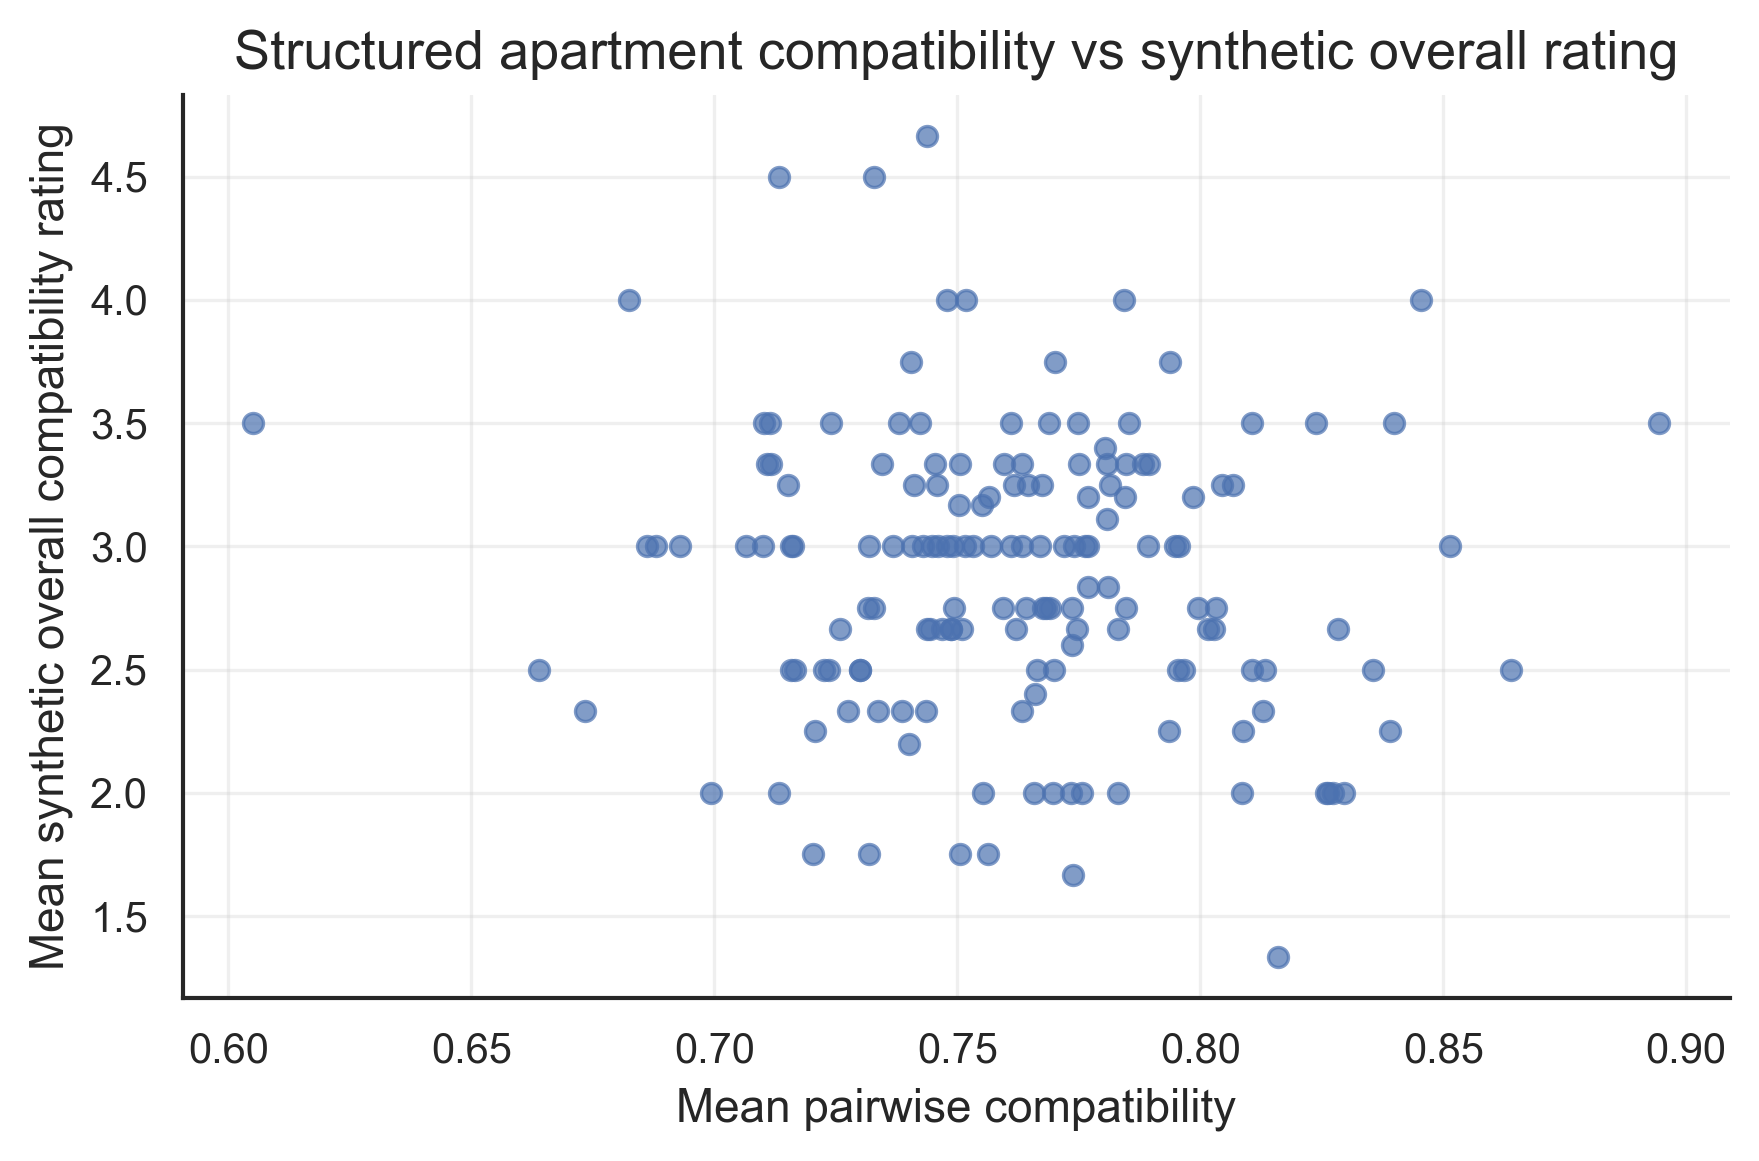

In [58]:
# ======================================
# 4.2 Visual comparison
# ======================================

plot_df_s4 = comparison_df_s4[
    ["mean_pair", "compatibility_overallrating_num"]
].dropna()

plt.figure(figsize=(6, 4), dpi=300)
plt.scatter(
    plot_df_s4["mean_pair"],
    plot_df_s4["compatibility_overallrating_num"],
    alpha=0.7
)

plt.xlabel("Mean pairwise compatibility")
plt.ylabel("Mean synthetic overall compatibility rating")
plt.title("Structured apartment compatibility vs synthetic overall rating")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 4.3 Illustrative Supervised Modelling with Synthetic Compatibility Outcomes

In [59]:
# ======================================
# 4.3 Illustrative supervised modelling:
# Version A = raw apartment-composition features only
# ======================================

from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr

# --------------------------------------------------
# 1. Define resident-level variables to aggregate
# --------------------------------------------------
# These are the raw apartment-composition inputs.
# Means capture the "average type" of apartment.
# Standard deviations capture within-apartment heterogeneity.

feature_cols = [
    "age",
    "apartmentsize",
    "extraversion",
    "agreeableness",
    "conscientiousness",
    "emotional_stability",
    "openness",
    "sleep_schedule_num",
    "noise_sensitivity_num",
    "cleanliness_num",
    "cooking_at_home_num",
    "guests_over_num",
    "smoking_num",
    "alcohol_num",
    "vibe_num",
    "chores_num",
    "conflict_num",
]

target_col = "compatibility_overallrating_num"

# Keep only needed columns
ml_df = merged_df[["apartment", "unit"] + feature_cols + [target_col]].copy()

# --------------------------------------------------
# 2. Build apartment-level dataset
# --------------------------------------------------
# One row = one apartment
# Target = mean synthetic overall compatibility rating per apartment
# Predictors = apartment size, resident count, means and stds of resident features

apartment_ml_df = (
    ml_df
    .groupby("apartment")
    .agg(
        n_residents=("unit", lambda x: x.dropna().astype(str).nunique()),
        target_mean=(target_col, "mean"),

        age_mean=("age", "mean"),
        age_std=("age", "std"),

        apartmentsize_mean=("apartmentsize", "mean"),

        extraversion_mean=("extraversion", "mean"),
        extraversion_std=("extraversion", "std"),

        agreeableness_mean=("agreeableness", "mean"),
        agreeableness_std=("agreeableness", "std"),

        conscientiousness_mean=("conscientiousness", "mean"),
        conscientiousness_std=("conscientiousness", "std"),

        emotional_stability_mean=("emotional_stability", "mean"),
        emotional_stability_std=("emotional_stability", "std"),

        openness_mean=("openness", "mean"),
        openness_std=("openness", "std"),

        sleep_schedule_mean=("sleep_schedule_num", "mean"),
        sleep_schedule_std=("sleep_schedule_num", "std"),

        noise_sensitivity_mean=("noise_sensitivity_num", "mean"),
        noise_sensitivity_std=("noise_sensitivity_num", "std"),

        cleanliness_mean=("cleanliness_num", "mean"),
        cleanliness_std=("cleanliness_num", "std"),

        cooking_at_home_mean=("cooking_at_home_num", "mean"),
        cooking_at_home_std=("cooking_at_home_num", "std"),

        guests_over_mean=("guests_over_num", "mean"),
        guests_over_std=("guests_over_num", "std"),

        smoking_mean=("smoking_num", "mean"),
        smoking_std=("smoking_num", "std"),

        alcohol_mean=("alcohol_num", "mean"),
        alcohol_std=("alcohol_num", "std"),

        vibe_mean=("vibe_num", "mean"),
        vibe_std=("vibe_num", "std"),

        chores_mean=("chores_num", "mean"),
        chores_std=("chores_num", "std"),

        conflict_mean=("conflict_num", "mean"),
        conflict_std=("conflict_num", "std"),
    )
    .reset_index()
)

# Apartments with a single resident have undefined std values.
# These will be imputed inside the modelling pipeline.
display(apartment_ml_df.head())

# --------------------------------------------------
# 3. Prepare X and y
# --------------------------------------------------
X = apartment_ml_df.drop(columns=["apartment", "target_mean"])
y = apartment_ml_df["target_mean"]

print("Apartment-level dataset shape:", apartment_ml_df.shape)
print("Number of apartments used:", len(apartment_ml_df))
print("Number of predictors:", X.shape[1])

# --------------------------------------------------
# 4. Define very light models
# --------------------------------------------------
# OLS = simple linear benchmark
# Ridge = slightly more stable version if predictors are correlated

ols_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

ridge_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=np.logspace(-3, 3, 25)))
])

# --------------------------------------------------
# 5. Leave-one-out cross-validation
# --------------------------------------------------
# This is suitable for a small apartment-level sample.
# Each apartment is predicted once while being left out of training.

loo = LeaveOneOut()

ols_pred = cross_val_predict(ols_model, X, y, cv=loo)
ridge_pred = cross_val_predict(ridge_model, X, y, cv=loo)

# --------------------------------------------------
# 6. Summarize predictive performance
# --------------------------------------------------
results = []

for model_name, pred in [("OLS", ols_pred), ("Ridge", ridge_pred)]:
    rmse = np.sqrt(mean_squared_error(y, pred))
    mae = mean_absolute_error(y, pred)
    r2 = r2_score(y, pred)
    rho, pval = spearmanr(y, pred)

    results.append({
        "model": model_name,
        "n_apartments": len(y),
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "spearman_rho": rho,
        "spearman_p_value": pval,
    })

results_df = pd.DataFrame(results).round(3)
display(results_df)

# --------------------------------------------------
# 7. Store predictions for later inspection / plotting
# --------------------------------------------------
apartment_predictions_df = apartment_ml_df[["apartment", "target_mean"]].copy()
apartment_predictions_df["pred_ols"] = ols_pred
apartment_predictions_df["pred_ridge"] = ridge_pred

display(apartment_predictions_df.head())

,apartment,n_residents,target_mean,age_mean,age_std,apartmentsize_mean,extraversion_mean,extraversion_std,agreeableness_mean,agreeableness_std,...,smoking_mean,smoking_std,alcohol_mean,alcohol_std,vibe_mean,vibe_std,chores_mean,chores_std,conflict_mean,conflict_std
0,PXA.01,2,4.000000,22.000000,4.242641,2.0,2.500000,0.000000,3.000000,0.000000,...,0.00,0.0,4.000000,0.000000,4.000000,0.000000,3.000000,1.414214,2.5,0.707107
1,PXA.02,2,2.500000,26.500000,2.121320,2.0,3.000000,0.707107,3.000000,0.707107,...,0.00,0.0,2.000000,1.414214,5.000000,0.000000,2.000000,0.000000,2.5,0.707107
2,PXA.03,4,2.750000,22.250000,4.573474,4.0,3.125000,0.250000,2.750000,0.500000,...,0.25,0.5,2.750000,0.500000,3.250000,0.957427,4.000000,1.414214,3.0,0.816497
3,PXA.04,3,2.666667,21.666667,4.163332,3.0,3.333333,0.577350,3.333333,0.763763,...,0.00,0.0,3.333333,0.577350,3.333333,1.527525,3.666667,1.154701,2.0,1.000000
4,PXA.05,4,3.000000,24.500000,3.696846,4.0,3.625000,0.853913,2.500000,0.707107,...,0.00,0.0,2.500000,0.577350,2.000000,2.000000,2.000000,1.154701,3.5,1.000000


Apartment-level dataset shape: (167, 36)
Number of apartments used: 167
Number of predictors: 34


,model,n_apartments,rmse,mae,r2,spearman_rho,spearman_p_value
0,OLS,167,0.740,0.561,-0.323,0.001,0.986
1,Ridge,167,0.649,0.505,-0.017,-0.079,0.308


,apartment,target_mean,pred_ols,pred_ridge
0,PXA.01,4.000000,2.551077,2.854001
1,PXA.02,2.500000,2.790012,2.846829
2,PXA.03,2.750000,2.432969,2.846837
3,PXA.04,2.666667,1.948841,2.788822
4,PXA.05,3.000000,2.425310,2.836096


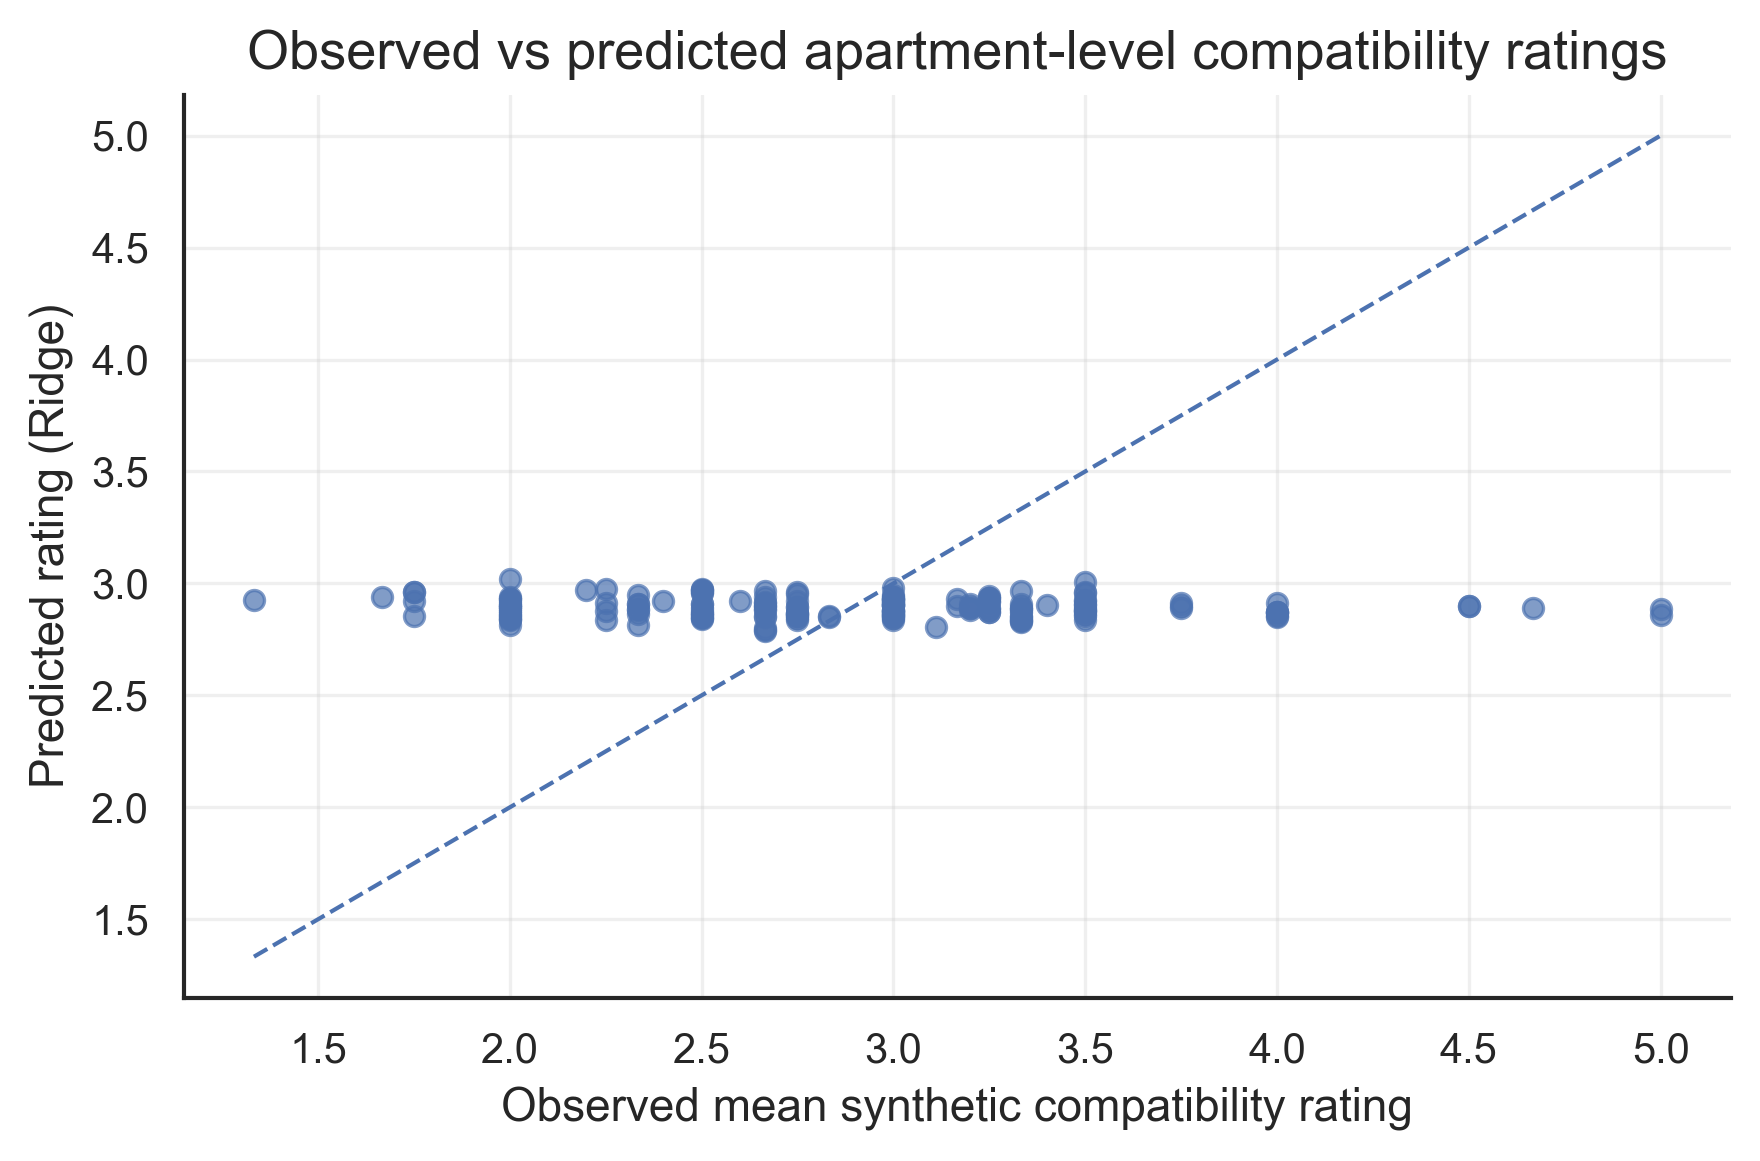

In [60]:
# ======================================
# 4.3 Visual check: observed vs predicted apartment ratings
# ======================================

plot_df_ml = apartment_predictions_df.copy()

plt.figure(figsize=(6, 4), dpi=300)
plt.scatter(
    plot_df_ml["target_mean"],
    plot_df_ml["pred_ridge"],
    alpha=0.7
)

# 45-degree reference line
min_val = min(plot_df_ml["target_mean"].min(), plot_df_ml["pred_ridge"].min())
max_val = max(plot_df_ml["target_mean"].max(), plot_df_ml["pred_ridge"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1)

plt.xlabel("Observed mean synthetic compatibility rating")
plt.ylabel("Predicted rating (Ridge)")
plt.title("Observed vs predicted apartment-level compatibility ratings")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

This extension has several important limitations and is included only as an illustrative proof of concept. The outcome variable is synthetic rather than observed, compatibility is not available at the pairwise level, and the modelling setup requires substantial aggregation of both apartment composition features and compatibility outcomes to mean apartment-level values. These simplifications remove much of the variation that would be necessary for meaningful prediction. Accordingly, the subsection is intended only to demonstrate the kind of light supervised pipeline that could have been implemented under richer data conditions, not to provide substantive predictive results.